# 1. Project Motivation
---
In autonomous driving, accurately interpreting visual information is essential for safe and efficient navigation. One important task is recognizing street house numbers, which helps identify locations, verify destinations, and support mapping in urban environments. This project develops a machine learning model using the Street View House Numbers (SVHN) dataset, which contains real-world images of digits captured from street scenes.

The SVHN dataset is well suited for this task because it reflects real driving challenges, including varying lighting conditions, background clutter, occlusions, and perspective changes. Compared to simpler datasets, it provides a more realistic benchmark for models intended for practical deployment.

Since this is a safety-relevant application, high accuracy and reliability are critical. Even small classification errors can lead to incorrect location identification or reduced reliability, so the model must demonstrate strong performance, robustness, and generalization.

To address this, the project applies deep learning techniques, particularly convolutional neural networks (CNNs), which are effective at capturing spatial features in images. A comparison with a baseline multilayer perceptron (MLP) is included to evaluate performance differences.

The overall goal is to build a reliable digit recognition system that contributes to the perception capabilities of modern autonomous vehicles.

# 2. Description of the Business Problem
---

The main objective of this project is to compare a baseline Multi-Layer Perceptron (MLP) with a CNN-based transfer learning model using pretrained ResNet50 on the SVHN dataset for use in a driverless car system. The comparison aims to determine which approach provides stronger recognition accuracy, generalization, and robustness under real-world visual conditions.

# 3. Description of the Dataset / Data Source
---

## 3.1 Description

Dataset: **Street View House Numbers (SVHN)**
- A real-world image dataset created for digit recognition using house numbers collected from Google Street View images.

- It is widely used in machine learning because it is more realistic and challenging than simpler datasets like MNIST, since the images come from natural street scenes

- For this project, Format 2 is used, which is the cropped digits format. In Format 2, each image is a cropped 32×32 RGB digit image, suitable for digit classification.

- Each image in Format 2 is a 32 × 32 color image (RGB). For the MLP baseline, each image is flattened into a 3072-dimensional vector. For the ResNet50 model, each image is resized to 224 × 224 during preprocessing to match the network input requirements.

- The dataset contains 10 classes, with 1 class for each digit. Digit '1' has label 1, digit '9' has label 9, and digit '0' has label 10.

- The complete dataset can be found on the Stanford UFLDL SVHN webpage: [The Street View House Numbers (SVHN) Dataset](http://ufldl.stanford.edu/housenumbers/)

## 3.2 Dataset Structure

The dataset is divided into three main `.mat` files and organized within the `data\` folder, as outlined below:

- `train_32x32.mat`: This file includes 73,257 digits for training set.
- `test_32x32.mat`: This file includes 26,032 digits for testing set.
- `extra_32x32.mat`: This file includes 531,131 additional digits that can be used as extra training data, if needed.

## 3.3 Load and Analyze the Data
In this section, we begin by setting up the working environment and preparing the dataset for analysis. If running in Google Colab, the workflow includes mounting the Google Drive to access project files and datasets. Next, we define the project directory structure, organizing paths for `data/`, `plots/`, and `saved_models/` to ensure consistency and reproducibility.
</br>
</br>
Once the environment is configured, the dataset is loaded and explored through initial analysis steps outlined in the **EDA in Section 4**.

In [ ]:
# Optional installation - uncomment and run if needed
#!pip install pandas numpy scipy seaborn scikit-learn matplotlib tensorflow torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 pandoc

In [ ]:
# ============================================
# Load SVHN data
# ============================================
import os
import gc
import math
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA

from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from pathlib import Path

# Detect Colab
IN_COLAB = False
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    # Teacher/Local Colab: change this one line only if folder is elsewhere
    PROJECT_ROOT = Path('/content/drive/MyDrive/tafe/src/svhn')
else:
    # Local machine: notebook is inside news
    PROJECT_ROOT = Path.cwd().resolve()

SAVED_MODELS_DIR = PROJECT_ROOT / 'saved_models'
PLOTS_DIR = PROJECT_ROOT / 'plots'
DATA_DIR = PROJECT_ROOT / 'data'

for d in [SAVED_MODELS_DIR, PLOTS_DIR, DATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SAVED_MODELS_DIR:", SAVED_MODELS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("DATA_DIR:", DATA_DIR)

os.makedirs("saved_models", exist_ok=True)
os.makedirs("plots", exist_ok=True)

def safe_torch_save(obj, path):
    path_obj = Path(path)
    temp_path_obj = path_obj.with_suffix(path_obj.suffix + ".tmp")
    torch.save(obj, temp_path_obj)
    os.replace(temp_path_obj, path_obj)

Mounted at /content/drive
IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/tafe/src/svhn
SAVED_MODELS_DIR: /content/drive/MyDrive/tafe/src/svhn/saved_models
PLOTS_DIR: /content/drive/MyDrive/tafe/src/svhn/plots
DATA_DIR: /content/drive/MyDrive/tafe/src/svhn/data


In [ ]:
# Check available files
print(os.listdir(DATA_DIR))

['train_32x32.mat', 'test_32x32.mat', 'extra_32x32.mat']


# 4. Exploratory Data Analysis (EDA) and Data Preparation Process

## 4.1 Dataset Exploration
The SVHN dataset was analysed to understand class distribution, image characteristics, and pixel intensity patterns. The dataset contains 32×32 RGB images of digits with relatively balanced class distribution. Visual inspection shows significant variability in digit placement, scale, and background noise, motivating the use of convolutional architectures and data augmentation.

**Dataset Loading and Inspection.** The SVHN (Street View House Numbers) dataset is stored in .mat (MATLAB format) files, which contain structured data such as images and labels.

In [ ]:
# Load .mat files
train_data = loadmat(DATA_DIR / "train_32x32.mat")
test_data = loadmat(DATA_DIR / "test_32x32.mat")
extra_data = loadmat(DATA_DIR / "extra_32x32.mat")

print("Train keys:", train_data.keys())
print("Test keys:", test_data.keys())
print("Extra keys:", extra_data.keys())

Train keys: dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])
Test keys: dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])
Extra keys: dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])


Each .mat file is loaded as a Python dictionary, and these are the keys inside it. `X` contains all image data which is in shape of `(32, 32, 3, N)` where `32 × 32` is the image size, `3` refers to the RGB channels and `N` to number of images. `y` consists of the labels `0-9`.

The raw image data (X) and labels (y) are then extracted and stored in separate variables for training and testing. We also flatten the labels so it's easier to work with in machine learning models and libraries.

In [ ]:
%%capture
# Extract raw arrays
X_train_main = train_data["X"]
y_train_main = train_data["y"].flatten()

X_extra = extra_data["X"]
y_extra = extra_data["y"].flatten()

X_test = test_data["X"]
y_test = test_data["y"].flatten()

# Free original dict containers
del train_data, test_data, extra_data
gc.collect()

**Label correction.** SVHN uses 10 to represent digit 0, so labels must be corrected by converting all 10 values to 0 before training models.

In [ ]:
# Fix labels: SVHN uses 10 for digit 0
y_train_main[y_train_main == 10] = 0
y_extra[y_extra == 10] = 0
y_test[y_test == 10] = 0

**Fixing SVHN Image Format.** SVHN images are stored with the sample dimension last, so we reshape the data by transposing it to match the standard input format required by deep learning models.

In [ ]:
# SVHN format is (H, W, C, N) -> convert to (N, H, W, C)
X_train_main = np.transpose(X_train_main, (3, 0, 1, 2))
X_extra = np.transpose(X_extra, (3, 0, 1, 2))
X_test = np.transpose(X_test, (3, 0, 1, 2))

print("Train main shape:", X_train_main.shape)
print("Extra shape:", X_extra.shape)
print("Test shape:", X_test.shape)

Train main shape: (73257, 32, 32, 3)
Extra shape: (531131, 32, 32, 3)
Test shape: (26032, 32, 32, 3)


Using all official training data plus a subset of the extra set balances improved model performance with reduced training time and computational cost.

In [ ]:
# ------------------------------------------------------------
# MEMORY-SAFE TRAINING POOL CREATION
# ------------------------------------------------------------
# Use all official train set + only a subset of extra set
# ------------------------------------------------------------

EXTRA_FRACTION = 1.00
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

extra_n = int(len(X_extra) * EXTRA_FRACTION)
extra_indices = np.random.choice(len(X_extra), extra_n, replace=False)

X_extra_subset = X_extra[extra_indices]
y_extra_subset = y_extra[extra_indices]

X_train = np.concatenate([X_train_main, X_extra_subset], axis=0)
y_train = np.concatenate([y_train_main, y_extra_subset], axis=0)

print("Final training pool shape:", X_train.shape)
print("Final training labels shape:", y_train.shape)
print("Test shape:", X_test.shape)

Final training pool shape: (604388, 32, 32, 3)
Final training labels shape: (604388,)
Test shape: (26032, 32, 32, 3)


In [ ]:

%%capture
# Free unused arrays to reduce RAM
del X_train_main, y_train_main, X_extra, y_extra, X_extra_subset, y_extra_subset, extra_indices
gc.collect()

**Class Distribution Analysis.** The distribution of digit samples (0–9) in the SVHN dataset was examined to assess whether the dataset is balanced across all classes before training the model.

{np.uint8(0): np.int64(50498), np.uint8(1): np.int64(104421), np.uint8(2): np.int64(85325), np.uint8(3): np.int64(69262), np.uint8(4): np.int64(58091), np.uint8(5): np.int64(60372), np.uint8(6): np.int64(47309), np.uint8(7): np.int64(49592), np.uint8(8): np.int64(40403), np.uint8(9): np.int64(39115)}
Plot already exists at /content/drive/MyDrive/tafe/src/svhn/plots/svhn_class_distribution.png. Loading it...


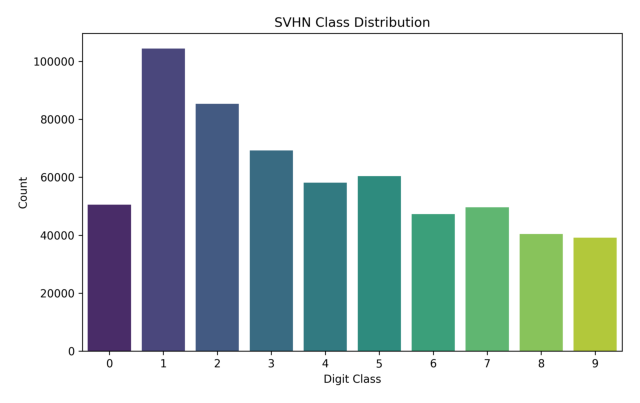

In [ ]:
class_distribution_path = PLOTS_DIR / "svhn_class_distribution.png"

def plot_class_distribution(y, class_distribution_path="svhn_class_distribution.png"):
    y_flat = np.array(y).flatten()
    classes, counts = np.unique(y_flat, return_counts=True)
    class_counts = dict(zip(classes, counts))
    print(class_counts)

    if os.path.exists(class_distribution_path):
        print(f"Plot already exists at {class_distribution_path}. Loading it...")
        img = mpimg.imread(class_distribution_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("SVHN Class Distribution")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {class_distribution_path}...")
        plt.figure(figsize=(8, 5))
        sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")
        plt.title("SVHN Class Distribution")
        plt.xlabel("Digit Class")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(class_distribution_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_class_distribution(y_train, class_distribution_path)

The chart above shows how many samples there are for each digit class (0-9) in the SVHN dataset. It can be seen that dataset is not perfectly balanced and some digits appear much more frequently than others. Example, digit 1 has the highest count (\~105,000) samples while digits 8 and 9 have the lowest (\~40,000) samples. Digits like 2, 3, 4, 5, 7 fall in the mid range (\~50k-85k).

Below is grid of randomly selected SVHN images to visually inspect sample digits and verify the dataset's quality and diversity:

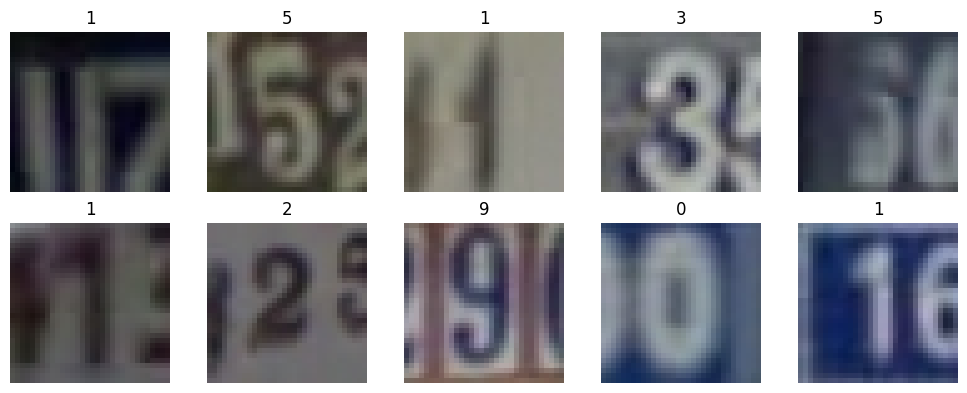

In [ ]:
# Example image grid (random samples)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    idx = np.random.randint(len(X_train))
    ax.imshow(X_train[idx])
    ax.set_title(str(y_train[idx]))
    ax.axis("off")

plt.tight_layout()
plt.show()

Plot already exists at /content/drive/MyDrive/tafe/src/svhn/plots/pixel_distribution.png. Loading it...


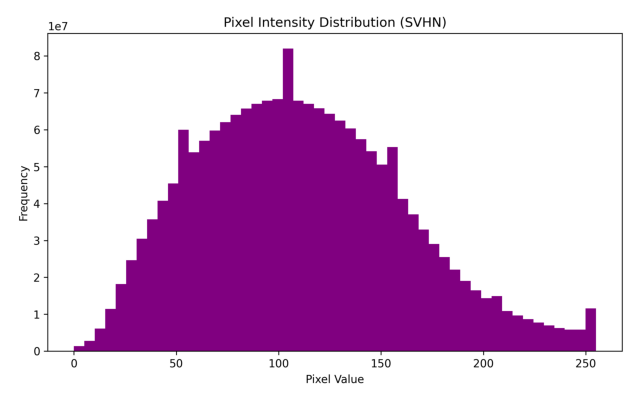

In [ ]:
# Pixel intensity distribution
pixel_distribution_path = PLOTS_DIR / "pixel_distribution.png"

def plot_pixel_distribution(X, save_path="pixel_distribution.png"):
    if os.path.exists(save_path):
        print(f"Plot already exists at {save_path}. Loading it...")
        img = mpimg.imread(save_path)
        plt.figure(figsize=(8, 5))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("Pixel Intensity Distribution (SVHN)")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {save_path}...")
        plt.figure(figsize=(8, 5))
        plt.hist(X.ravel(), bins=50, color="purple")
        plt.title("Pixel Intensity Distribution (SVHN)")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_pixel_distribution(X_train, pixel_distribution_path)

The pixel intensity distribution above shows that most SVHN images contain pixel values in the mid-range, typically around 80 to 150, indicating that the images are generally moderately bright rather than extremely dark or bright. Very low pixel values (close to 0) and very high values (close to 255) occur less frequently, suggesting that extreme lighting conditions are rare in the dataset. The distribution follows a roughly bell-shaped pattern, which reflects a natural variation in illumination across images, with a slight skew toward higher intensity values, indicating the presence of some brighter regions. Overall, this balanced distribution is beneficial for model training, as it provides diverse yet stable input data and supports effective learning after normalization.

Plot already exists at /content/drive/MyDrive/tafe/src/svhn/plots/mean_image.png. Loading it...


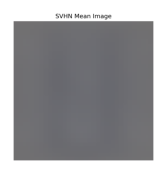

In [ ]:
# Mean image
mean_image_path = PLOTS_DIR / "mean_image.png"

def plot_mean_image(X, save_path="mean_image.png"):
    if os.path.exists(save_path):
        print(f"Plot already exists at {save_path}. Loading it...")
        img = mpimg.imread(save_path)
        plt.figure(figsize=(2, 2))
        plt.imshow(img)
        plt.axis("off")
        #plt.title("SVHN Mean Image")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {save_path}...")
        mean_img = np.mean(X, axis=0).astype(np.uint8)
        plt.figure(figsize=(2, 2))
        plt.imshow(mean_img)
        plt.title("SVHN Mean Image")
        plt.axis("off")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_mean_image(X_train, mean_image_path)

The mean image above represents the average pixel values across all SVHN images, resulting in a blurred, gray image that reflects overall brightness and common spatial patterns rather than individual digits.

Plot already exists at /content/drive/MyDrive/tafe/src/svhn/plots/std_image.png. Loading it...


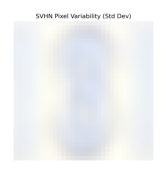

In [ ]:
# Standard deviation image
std_image_path = PLOTS_DIR / "std_image.png"

def plot_std_image(X, save_path="std_image.png"):
    if os.path.exists(save_path):
        print(f"Plot already exists at {save_path}. Loading it...")
        img = mpimg.imread(save_path)
        plt.figure(figsize=(2, 2))
        plt.imshow(img)
        plt.axis("off")
        # plt.title("SVHN Pixel Variability (Std Dev)")
        plt.show()
    else:
        print(f"Plot not found. Creating and saving to {save_path}...")
        std_img = np.std(X, axis=0)
        plt.figure(figsize=(2, 2))
        plt.imshow(std_img / (std_img.max() + 1e-8))
        plt.title("SVHN Pixel Variability (Std Dev)")
        plt.axis("off")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()

plot_std_image(X_train, std_image_path)

While, the SVHN Pixel Variability (Standard Deviation) Image above represents how much each pixel varies in intensity across all images. It shows that the central region of SVHN images has the highest variation (confirms that digits are generally centered), while outer regions are more consistent, indicating less informative background areas.

PCA was applied only as an exploratory data analysis technique to better understand the SVHN dataset, rather than as part of the actual model training process.

In [ ]:
# PCA on subset only for EDA
X_sub = X_train[:5000].reshape(5000, -1).astype(np.float32) / 255.0

pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_sub)

print("Shape after PCA:", X_pca.shape)
print("Explained variance ratio (first 10):", pca.explained_variance_ratio_[:10])

Shape after PCA: (5000, 50)
Explained variance ratio (first 10): [0.59053916 0.05579749 0.04904586 0.03992632 0.02057732 0.01840837
 0.01550315 0.01367459 0.01249037 0.01117182]


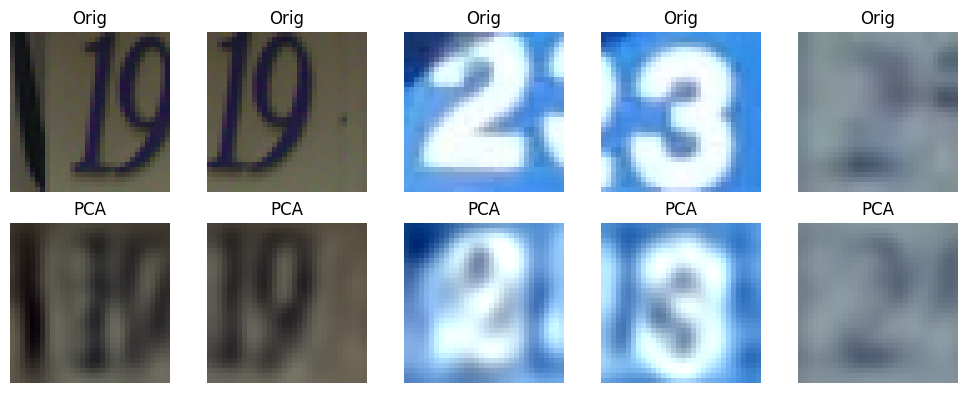

In [ ]:
X_reconstructed = pca.inverse_transform(X_pca)

plt.figure(figsize=(10, 4))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_sub[i].reshape(32, 32, 3))
    plt.title("Orig")
    plt.axis("off")

    plt.subplot(2, 5, i + 6)
    plt.imshow(np.clip(X_reconstructed[i].reshape(32, 32, 3), 0, 1))
    plt.title("PCA")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
%%capture
del X_sub, X_pca, X_reconstructed, pca
gc.collect()

The PCA results above show that the main shapes and digits are preserved, meaning the numbers remain visually identifiable after dimensionality reduction. However, there is an obvious loss of fine detail, visible in the blurrier and smoother PCA reconstructions. This happens because high-frequency image details are contained in later principal components that were discarded. Even so, the main colour patterns and contrast structure remain visible between the original and reconstructed images.

## 4.2 Data Pre-Processing
The dataset was preprocessed separately for the MLP and CNN models. A training-validation split was created from the sampled training set, while the original SVHN test set was kept untouched for final evaluation.

In [ ]:
# ------------------------------------------------------------
# SPLIT TRAIN / VALIDATION
# ------------------------------------------------------------
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.1,
    random_state=SEED,
    stratify=y_train
)

print("Train split:", X_train_split.shape)
print("Validation split:", X_val.shape)
print("Test:", X_test.shape)

Train split: (543949, 32, 32, 3)
Validation split: (60439, 32, 32, 3)
Test: (26032, 32, 32, 3)


In [ ]:
%%capture
# Free the old pool
del X_train, y_train
gc.collect()

### 4.2.1 MLP Data Pre-Processing
This section prepares the SVHN image data for input into the Mixer-MLP model by:
- Standardizing pixel values using statistics computed from the training set only.
- Apply the same normalization to training, validation, and test data.
- Convert the processed data into PyTorch tensors.
- Ensure correct data types are used.
- Organize the data into TensorDatasets for training, validation, and testing.
- Prepare datasets in a format suitable for the Mixer-MLP training pipeline.

In [ ]:
# ------------------------------------------------------------
# MLP PREPROCESSING
# ------------------------------------------------------------
# Standardize using train statistics only
# ------------------------------------------------------------
mlp_mean = X_train_split.mean(axis=(0, 1, 2), keepdims=True).astype(np.float32)
mlp_std = X_train_split.std(axis=(0, 1, 2), keepdims=True).astype(np.float32) + 1e-7

X_train_mlp = (X_train_split.astype(np.float32) - mlp_mean) / mlp_std
X_val_mlp   = (X_val.astype(np.float32) - mlp_mean) / mlp_std
X_test_mlp  = (X_test.astype(np.float32) - mlp_mean) / mlp_std

In [ ]:
print("Mixer train shape:", X_train_mlp.shape)
print("Mixer val shape:", X_val_mlp.shape)
print("Mixer test shape:", X_test_mlp.shape)

Mixer train shape: (543949, 32, 32, 3)
Mixer val shape: (60439, 32, 32, 3)
Mixer test shape: (26032, 32, 32, 3)


In [ ]:
# Convert to PyTorch tensors
X_train_mlp_tensor = torch.tensor(X_train_mlp, dtype=torch.float32)
y_train_mlp_tensor = torch.tensor(y_train_split, dtype=torch.long)

X_val_mlp_tensor = torch.tensor(X_val_mlp, dtype=torch.float32)
y_val_mlp_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_mlp_tensor = torch.tensor(X_test_mlp, dtype=torch.float32)
y_test_mlp_tensor = torch.tensor(y_test, dtype=torch.long)

In [ ]:
# MLP datasets
mlp_train_dataset = TensorDataset(X_train_mlp_tensor, y_train_mlp_tensor)
mlp_val_dataset = TensorDataset(X_val_mlp_tensor, y_val_mlp_tensor)
mlp_test_dataset = TensorDataset(X_test_mlp_tensor, y_test_mlp_tensor)

### 4.2.2 CNN Data Pre-Processing
This section prepares the SVHN image data for input into the ResNet50 model by:
- Load the default pretrained ResNet50 weights and extract the corresponding ImageNet normalization statistics.
- Define a training transform pipeline with resizing, data augmentation, tensor conversion, and normalization.
- Define an evaluation transform pipeline with resizing, tensor conversion, and normalization only.
- Use a custom SVHN dataset class so image transformations are applied dynamically during loading.
- Convert each image to uint8 format and return the corresponding label for training.
- Create a smaller training subset specifically for ResNet50 to reduce computational cost.
- Keep the validation and test sets unchanged for fair evaluation.
- Build separate training, validation, and test datasets using the appropriate transforms.

In [ ]:
# ------------------------------------------------------------
# RESNET PREPROCESSING
# ------------------------------------------------------------
# Use a custom dataset so resizing happens on-the-fly
# ------------------------------------------------------------
weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

resnet_train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

resnet_eval_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

In [ ]:
class SVHNDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].astype(np.uint8)
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# ------------------------------------------------------------
# SMALLER TRAINING SUBSET FOR RESNET50
# ------------------------------------------------------------
# This does NOT affect MLP training.
# It creates a separate reduced dataset only for ResNet50.
# ------------------------------------------------------------
# Use only part of the training data for ResNet50
# Example: 70% of available training split

X_train_resnet_subset, _, y_train_resnet_subset, _ = train_test_split(
    X_train_split,
    y_train_split,
    train_size=0.8,
    stratify=y_train_split,
    random_state=SEED
)

print("Original ResNet training size:", len(X_train_split))
print("Reduced ResNet training size:", len(X_train_resnet_subset))

Original ResNet training size: 543949
Reduced ResNet training size: 435159


In [ ]:
# Create datasets for ResNet
resnet_train_dataset = SVHNDataset(X_train_resnet_subset, y_train_resnet_subset, transform=resnet_train_transform)
resnet_val_dataset = SVHNDataset(X_val, y_val, transform=resnet_eval_transform)
resnet_test_dataset = SVHNDataset(X_test, y_test, transform=resnet_eval_transform)

## 4.3 Device Setup
**Hardware Configuration.** Model training and evaluation were performed using PyTorch with automatic device selection. GPU acceleration was utilized when available to improve computational efficiency; otherwise, computations were executed on the CPU.

In [ ]:
%%capture
# ------------------------------------------------------------
# DEVICE SELECTION
# ------------------------------------------------------------
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA:", device)
else:
    device = torch.device("cpu")
    print("Using CPU:", device)

# 5. Methodology Used for Training, Testing, and Evaluation
---
To evaluate the effectiveness of different deep learning approaches for SVHN digit classification, two categories of models were investigated: a Mixer-MLP model representing multilayer perceptron–based architectures, and a convolutional neural network model based on ResNet50. The Mixer-MLP model was selected for its ability to model global spatial interactions without convolution, while the ResNet50 model was chosen for its strong capability to capture hierarchical spatial features and its proven performance in image classification tasks.
</br>
</br>
To identify the most effective model configurations, a systematic hyperparameter search and training procedure was performed for each architecture. The process involved evaluating multiple hyperparameter combinations, monitoring validation performance, and selecting the best-performing model based on validation accuracy.

### 5.1 Model 1: MLP
A multilayer perceptron (MLP) is a type of neural network composed of fully connected layers that learns patterns by transforming input features through nonlinear activations, making it a simple yet effective baseline for classification tasks.

#### 5.1.1 Mixer-MLP Architecture
Mixer-MLP is a neural network architecture that processes images by dividing them into patches and applying multilayer perceptrons (MLPs) to capture both spatial and channel-wise relationships, without using convolution or attention mechanisms. It is used for the SVHN dataset to efficiently model global interactions between image regions while maintaining a relatively simple and lightweight structure for digit classification.


In [ ]:
class MixerBlock(nn.Module):
    def __init__(self, num_patches, hidden_dim, tokens_mlp_dim, channels_mlp_dim, dropout_rate=0.2):
        super().__init__()

        self.token_norm = nn.LayerNorm(hidden_dim)
        self.token_mlp = nn.Sequential(
            nn.Linear(num_patches, tokens_mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(tokens_mlp_dim, num_patches),
            nn.Dropout(dropout_rate)
        )

        self.channel_norm = nn.LayerNorm(hidden_dim)
        self.channel_mlp = nn.Sequential(
            nn.Linear(hidden_dim, channels_mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout_rate),
            nn.Linear(channels_mlp_dim, hidden_dim),
            nn.Dropout(dropout_rate)
        )

    def forward(self, x):
        # x: (B, num_patches, hidden_dim)

        # Token mixing
        y = self.token_norm(x)
        y = y.transpose(1, 2)              # (B, hidden_dim, num_patches)
        y = self.token_mlp(y)
        y = y.transpose(1, 2)              # back to (B, num_patches, hidden_dim)
        x = x + y

        # Channel mixing
        y = self.channel_norm(x)
        y = self.channel_mlp(y)
        x = x + y

        return x


class MixerMLP(nn.Module):
    def __init__(
        self,
        image_size=32,
        patch_size=4,
        in_channels=3,
        num_classes=10,
        hidden_dim=128,
        num_blocks=4,
        tokens_mlp_dim=64,
        channels_mlp_dim=256,
        dropout_rate=0.2
    ):
        super().__init__()

        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"

        self.num_patches_per_side = image_size // patch_size
        self.num_patches = self.num_patches_per_side ** 2
        patch_dim = patch_size * patch_size * in_channels

        self.patch_size = patch_size

        self.patch_embed = nn.Linear(patch_dim, hidden_dim)

        self.mixer_blocks = nn.Sequential(*[
            MixerBlock(
                num_patches=self.num_patches,
                hidden_dim=hidden_dim,
                tokens_mlp_dim=tokens_mlp_dim,
                channels_mlp_dim=channels_mlp_dim,
                dropout_rate=dropout_rate
            )
            for _ in range(num_blocks)
        ])

        self.final_norm = nn.LayerNorm(hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x expected shape: (B, 32*32*3) or (B, 3, 32, 32)

        if x.dim() == 2:
            x = x.view(-1, 32, 32, 3)

        if x.dim() == 4 and x.shape[1] == 3:
            # (B, C, H, W) -> (B, H, W, C)
            x = x.permute(0, 2, 3, 1)

        B, H, W, C = x.shape
        P = self.patch_size

        # Split into non-overlapping patches
        x = x.view(B, H // P, P, W // P, P, C)
        x = x.permute(0, 1, 3, 2, 4, 5)            # (B, h_patches, w_patches, P, P, C)
        x = x.reshape(B, self.num_patches, P * P * C)

        # Patch embedding
        x = self.patch_embed(x)                    # (B, num_patches, hidden_dim)

        # Mixer blocks
        x = self.mixer_blocks(x)

        # Global average over patches
        x = self.final_norm(x)
        x = x.mean(dim=1)

        return self.classifier(x)

#### 5.1.2 Mixer-MLP Hyperparameters Tuning
Hyperparameter tuning was performed by testing several combinations of learning rate, batch size, dropout rate, number of epochs and hidden units. For each configuration, the model was trained and the best checkpoint based on validation accuracy was saved. The saved models were then compared, and the one with the highest validation accuracy was selected for final testing. **For full details on the hyperparameter search and model training, refer to Appendix B.**

In [ ]:
mlp_param_grid = [
    {
        "learning_rate": 0.0005,
        "batch_size": 128,
        "dropout_rate": 0.20,
        "num_epochs": 40,
        "hidden_dim": 128,
        "num_blocks": 6,
        "tokens_mlp_dim": 64,
        "channels_mlp_dim": 256
    },
    {
        "learning_rate": 0.0003,
        "batch_size": 64,
        "dropout_rate": 0.30,
        "num_epochs": 50,
        "hidden_dim": 192,
        "num_blocks": 6,
        "tokens_mlp_dim": 96,
        "channels_mlp_dim": 384
    },
    {
        "learning_rate": 0.001,
        "batch_size": 128,
        "dropout_rate": 0.20,
        "num_epochs": 30,
        "hidden_dim": 128,
        "num_blocks": 4,
        "tokens_mlp_dim": 64,
        "channels_mlp_dim": 256
    },
    {
        "learning_rate": 0.0003,
        "batch_size": 64,
        "dropout_rate": 0.20,
        "num_epochs": 80,
        "hidden_dim": 256,
        "num_blocks": 8,
        "tokens_mlp_dim": 128,
        "channels_mlp_dim": 512
    },
    {
        "learning_rate": 0.0003,
        "batch_size": 64,
        "dropout_rate": 0.10,
        "num_epochs": 80,
        "hidden_dim": 384,
        "num_blocks": 6,
        "tokens_mlp_dim": 192,
        "channels_mlp_dim": 768
    },
    {
        "learning_rate": 0.0002,
        "batch_size": 32,
        "dropout_rate": 0.10,
        "num_epochs": 100,
        "hidden_dim": 512,
        "num_blocks": 8,
        "tokens_mlp_dim": 256,
        "channels_mlp_dim": 1024
    }
]

mlp_experiment_results = []
mlp_all_histories = {}

#### 5.1.3 Mixer-MLP Training

In [ ]:
# ----------------------------
# Global resume tracking for MLP
# ----------------------------
mlp_total_experiments = len(mlp_param_grid)
mlp_resume_experiment = 1
mlp_global_checkpoint = SAVED_MODELS_DIR / "mlp_hparam_search_state.pth"

mlp_all_done = False

if mlp_global_checkpoint.exists():
    print("Global MLP experiment checkpoint found...")
    # Fix: Add weights_only=False to torch.load as the checkpoint contains pathlib.PosixPath objects.
    mlp_global_state = torch.load(mlp_global_checkpoint, map_location=device, weights_only=False)

    saved_idx = mlp_global_state.get("experiment_idx", 1)
    mlp_experiment_results = mlp_global_state.get("experiment_results", [])
    mlp_all_histories = mlp_global_state.get("all_histories", {})

    if saved_idx > mlp_total_experiments:
        mlp_all_done = True
        mlp_resume_experiment = mlp_total_experiments + 1
        print(f"All {mlp_total_experiments} MLP experiments are already completed.")
    else:
        mlp_resume_experiment = max(1, saved_idx)
        print(f"Resuming from MLP experiment {mlp_resume_experiment} of {mlp_total_experiments}")
else:
    print("No global MLP experiment checkpoint found.")

Global MLP experiment checkpoint found...
All 6 MLP experiments are already completed.


In [ ]:
# =====================================================================================
# MLP HYPERPARAMETER SEARCH
# =====================================================================================
if mlp_all_done:
    print("Skipping MLP hyperparameter search.")
else:
  for exp_idx, params in enumerate(mlp_param_grid, start=1):

      if exp_idx < mlp_resume_experiment:
          print(f"Skipping completed MLP experiment {exp_idx}")
          continue

      print("=" * 100)
      print(f"MLP Experiment {exp_idx}/{len(mlp_param_grid)}")
      print("Parameters:", params)
      print("=" * 100)

      mlp_train_loader = DataLoader(mlp_train_dataset, batch_size=params["batch_size"], shuffle=True, num_workers=0, drop_last=False)
      mlp_val_loader = DataLoader(mlp_val_dataset, batch_size=params["batch_size"], shuffle=False, num_workers=0, drop_last=False )

      mlp_model = MixerMLP(
          image_size=32,
          patch_size=4,
          in_channels=3,
          num_classes=10,
          hidden_dim=params["hidden_dim"],
          num_blocks=params["num_blocks"],
          tokens_mlp_dim=params["tokens_mlp_dim"],
          channels_mlp_dim=params["channels_mlp_dim"],
          dropout_rate=params["dropout_rate"]
      ).to(device)

      mlp_criterion = nn.CrossEntropyLoss()
      mlp_optimizer = optim.AdamW(
          mlp_model.parameters(),
          lr=params["learning_rate"],
          weight_decay=1e-4
      )

      mlp_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
          mlp_optimizer,
          mode="max",
          factor=0.5,
          patience=2
      )

      best_val_acc = 0.0
      best_val_loss = float("inf")
      best_epoch = 0
      best_model_state_dict = None

      patience = 7
      epochs_without_improvement = 0

      train_losses, val_losses = [], []
      train_accuracies, val_accuracies = [], []

      lr_str = str(params["learning_rate"]).replace(".", "_")
      drop_str = str(params["dropout_rate"]).replace(".", "_")

      checkpoint_name = (
      SAVED_MODELS_DIR / f"mixer_exp{exp_idx}_"
      f"lr{lr_str}_bs{params['batch_size']}_drop{drop_str}_"
      f"hd{params['hidden_dim']}_b{params['num_blocks']}_"
      f"tm{params['tokens_mlp_dim']}_cm{params['channels_mlp_dim']}.pth"
      )

      start_epoch = 0

      if os.path.exists(checkpoint_name):
          print("MLP checkpoint found. Resuming training...")
          checkpoint = torch.load(checkpoint_name, map_location=device)

          mlp_model.load_state_dict(checkpoint["latest_model_state_dict"])
          mlp_optimizer.load_state_dict(checkpoint["latest_optimizer_state_dict"])

          start_epoch = checkpoint.get("epoch", 0)
          best_val_acc = checkpoint.get("best_val_acc", 0.0)
          best_val_loss = checkpoint.get("best_val_loss", float("inf"))
          best_epoch = checkpoint.get("best_epoch", 0)
          best_model_state_dict = checkpoint.get("best_model_state_dict", None)
          epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

          train_losses = checkpoint.get("train_losses", [])
          val_losses = checkpoint.get("val_losses", [])
          train_accuracies = checkpoint.get("train_accuracies", [])
          val_accuracies = checkpoint.get("val_accuracies", [])

          print(f"Resuming MLP from epoch {start_epoch}")
      else:
          print("No MLP experiment checkpoint found. Starting fresh.")

      start_time = time.time()

      for epoch in range(start_epoch, params["num_epochs"]):
          mlp_model.train()

          running_loss = 0.0
          correct = 0
          total = 0

          epoch_start = time.time()

          for images, labels in mlp_train_loader:
              images = images.to(device)
              labels = labels.to(device)

              mlp_optimizer.zero_grad()
              outputs = mlp_model(images)
              loss = mlp_criterion(outputs, labels)
              loss.backward()
              mlp_optimizer.step()

              running_loss += loss.item() * images.size(0)
              _, predicted = torch.max(outputs, 1)
              total += labels.size(0)
              correct += (predicted == labels).sum().item()

          epoch_train_loss = running_loss / total
          epoch_train_acc = correct / total

          train_losses.append(epoch_train_loss)
          train_accuracies.append(epoch_train_acc)

          # Validation
          mlp_model.eval()
          val_running_loss = 0.0
          val_correct = 0
          val_total = 0

          with torch.no_grad():
              for images, labels in mlp_val_loader:
                  images = images.to(device)
                  labels = labels.to(device)

                  outputs = mlp_model(images)
                  loss = mlp_criterion(outputs, labels)

                  val_running_loss += loss.item() * images.size(0)
                  _, predicted = torch.max(outputs, 1)
                  val_total += labels.size(0)
                  val_correct += (predicted == labels).sum().item()

          epoch_val_loss = val_running_loss / val_total
          epoch_val_acc = val_correct / val_total

          val_losses.append(epoch_val_loss)
          val_accuracies.append(epoch_val_acc)

          mlp_scheduler.step(epoch_val_acc)

          epoch_duration = time.time() - epoch_start

          print(
              f"Epoch [{epoch+1}/{params['num_epochs']}] "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Train Acc: {epoch_train_acc:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, "
              f"Val Acc: {epoch_val_acc:.4f}, "
              f"LR: {mlp_optimizer.param_groups[0]['lr']:.6f}, "
              f"Time: {epoch_duration:.2f}s"
          )

          if epoch_val_acc > best_val_acc:
              best_val_acc = epoch_val_acc
              best_val_loss = epoch_val_loss
              best_epoch = epoch + 1
              epochs_without_improvement = 0

              best_model_state_dict = {
                  k: v.detach().cpu().clone()
                  for k, v in mlp_model.state_dict().items()
              }

              print("Best MLP model improved.")
          else:
              epochs_without_improvement += 1

          total_elapsed = time.time() - start_time

          safe_torch_save({
              "epoch": epoch + 1,
              "experiment_idx": exp_idx,
              "latest_model_state_dict": mlp_model.state_dict(),
              "latest_optimizer_state_dict": mlp_optimizer.state_dict(),
              "best_model_state_dict": best_model_state_dict,
              "best_val_acc": best_val_acc,
              "best_val_loss": best_val_loss,
              "best_epoch": best_epoch,
              "val_acc": epoch_val_acc,
              "val_loss": epoch_val_loss,
              "epochs_without_improvement": epochs_without_improvement,
              "params": params,
              "total_training_time_sec": total_elapsed,
              "train_losses": train_losses,
              "val_losses": val_losses,
              "train_accuracies": train_accuracies,
              "val_accuracies": val_accuracies
          }, checkpoint_name)

          if epochs_without_improvement >= patience:
              print(f"Early stopping at epoch {epoch+1}")
              break

      mlp_experiment_results = [r for r in mlp_experiment_results if r["experiment"] != exp_idx]
      mlp_experiment_results.append({
          "experiment": exp_idx,
          "learning_rate": params["learning_rate"],
          "batch_size": params["batch_size"],
          "dropout_rate": params["dropout_rate"],
          "hidden_dim": params["hidden_dim"],
          "num_blocks": params["num_blocks"],
          "tokens_mlp_dim": params["tokens_mlp_dim"],
          "channels_mlp_dim": params["channels_mlp_dim"],
          "num_epochs": params["num_epochs"],
          "best_val_acc": best_val_acc,
          "best_val_loss": best_val_loss,
          "best_epoch": best_epoch,
          "checkpoint": checkpoint_name
      })

      mlp_all_histories[checkpoint_name] = {
          "train_losses": train_losses,
          "val_losses": val_losses,
          "train_accuracies": train_accuracies,
          "val_accuracies": val_accuracies
      }

      safe_torch_save({
          "experiment_idx": exp_idx + 1,
          "experiment_results": mlp_experiment_results,
          "all_histories": mlp_all_histories
      }, mlp_global_checkpoint)

      gc.collect()
      if torch.cuda.is_available():
          torch.cuda.empty_cache()

Skipping MLP hyperparameter search.


#### 5.1.4 Mixer-MLP Evaluation

In [ ]:
mlp_results_df = pd.DataFrame(mlp_experiment_results)
mlp_results_df = mlp_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)

print("\nMLP Tuning Results:")
print(mlp_results_df)

mlp_results_df.to_csv(SAVED_MODELS_DIR / "mlp_hyperparameter_results.csv", index=False)
print(f"Saved tuning results to {SAVED_MODELS_DIR}/mlp_hyperparameter_results.csv")


MLP Tuning Results:
   experiment  learning_rate  batch_size  dropout_rate  hidden_dim  \
0           2         0.0003          64           0.3         192   
1           1         0.0005         128           0.2         128   
2           4         0.0003          64           0.2         256   
3           6         0.0002          32           0.1         512   
4           5         0.0003          64           0.1         384   
5           3         0.0010         128           0.2         128   

   num_blocks  tokens_mlp_dim  channels_mlp_dim  num_epochs  best_val_acc  \
0           6              96               384          50      0.980245   
1           6              64               256          40      0.979583   
2           8             128               512          80      0.979517   
3           8             256              1024         100      0.979037   
4           6             192               768          80      0.978987   
5           4             

##### 5.1.4.1 Load Best Mixer-MLP Model for Evaluation
Load the saved `.pth` checkpoint and set model to evaluation mode.

In [ ]:
best_mlp_checkpoint_path = PROJECT_ROOT / mlp_results_df.iloc[0]["checkpoint"]
print("Best Mixer-MLP checkpoint selected:", best_mlp_checkpoint_path)

Best Mixer-MLP checkpoint selected: /content/drive/MyDrive/tafe/src/svhn/saved_models/mixer_exp2_lr0_0003_bs64_drop0_3_hd192_b6_tm96_cm384.pth


In [ ]:
%%capture
mlp_checkpoint = torch.load(best_mlp_checkpoint_path, map_location="cpu")
best_mlp_params = mlp_checkpoint["params"]

best_model_mlp = MixerMLP(
    image_size=32,
    patch_size=4,
    in_channels=3,
    num_classes=10,
    hidden_dim=best_mlp_params["hidden_dim"],
    num_blocks=best_mlp_params["num_blocks"],
    tokens_mlp_dim=best_mlp_params["tokens_mlp_dim"],
    channels_mlp_dim=best_mlp_params["channels_mlp_dim"],
    dropout_rate=best_mlp_params["dropout_rate"]
).to(device)

if mlp_checkpoint["best_model_state_dict"] is None:
    raise ValueError("Best Mixer-MLP model state dict is None. Training may not have completed properly.")

best_model_mlp.load_state_dict(mlp_checkpoint["best_model_state_dict"])
best_model_mlp.eval()

##### 5.1.4.2 Training History Analysis of Best Mixer-MLP Model
These plots show the best model’s training/validation loss accuracy curves.

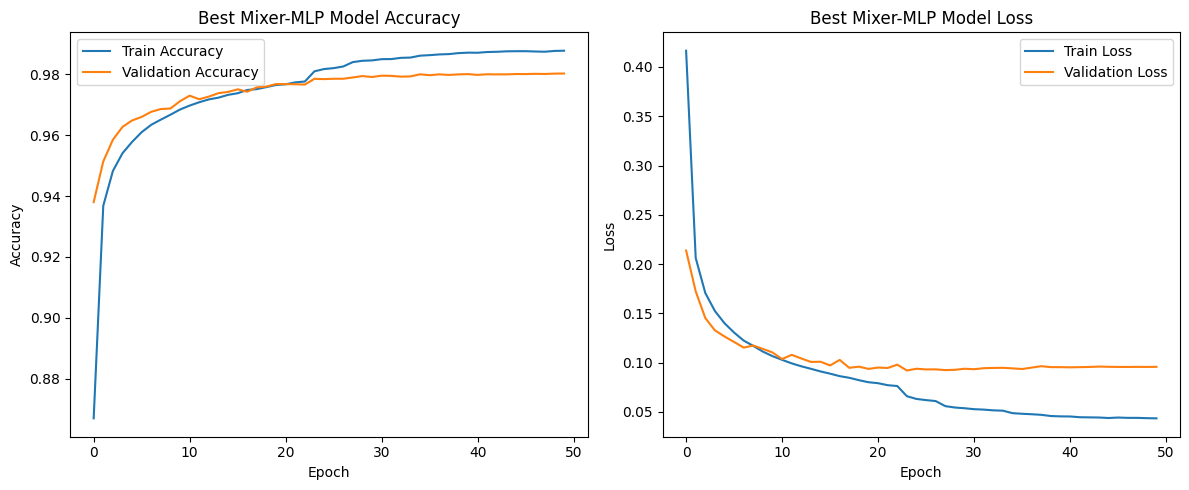

In [ ]:
best_mlp_history = mlp_all_histories[mlp_results_df.iloc[0]["checkpoint"]]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_mlp_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_mlp_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best Mixer-MLP Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_mlp_history["train_losses"], label="Train Loss")
plt.plot(best_mlp_history["val_losses"], label="Validation Loss")
plt.title("Best Mixer-MLP Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The performance of the best Mixer-MLP model over the training period demonstrates strong learning
capability and stable convergence. As shown in the accuracy plot, the model achieves rapid
improvement during the initial epochs, with training accuracy increasing sharply from approximately
87% to over 95% within a few iterations. Both training and validation accuracy continue to rise
steadily, eventually reaching around 99% and 98%, respectively. The small gap between the two
curves indicates that the model generalizes well to unseen data with minimal overfitting. Similarly, the
loss curves show a significant reduction during the early stages of training, with both training and
validation loss dropping quickly before gradually stabilizing. The training loss continues to decrease
to a low value, while the validation loss plateaus at a slightly higher level, suggesting a minor degree
of overfitting but overall stable performance. Overall, these results indicate that the Mixer-MLP model
is able to efficiently learn discriminative features from the SVHN dataset, achieving high accuracy with
good generalization and consistent training behavior.


##### 5.1.4.3 Mixer-MLP Evaluation on Validation Dataset

In [ ]:
best_batch_size_mlp = best_mlp_params["batch_size"]

mlp_val_loader = DataLoader(
    mlp_val_dataset,
    batch_size=best_batch_size_mlp,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_preds_mlp = []
val_labels_mlp = []

with torch.no_grad():
    for images, labels in mlp_val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model_mlp(images)
        _, predicted = torch.max(outputs, 1)

        val_preds_mlp.extend(predicted.cpu().numpy())
        val_labels_mlp.extend(labels.cpu().numpy())

val_preds_mlp = np.array(val_preds_mlp)
val_labels_mlp = np.array(val_labels_mlp)

val_accuracy_mlp = (val_preds_mlp == val_labels_mlp).mean()
print(f"Mixer-MLP Validation Accuracy: {val_accuracy_mlp:.4f}")

Mixer-MLP Validation Accuracy: 0.9802


In [ ]:
# ----------------------------
# Classification Report
# ----------------------------
class_names = [str(i) for i in range(10)]

print("\nMixer-MLP Classification Report on Validation Set:")
print(classification_report(val_labels_mlp, val_preds_mlp, target_names=class_names))


Mixer-MLP Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      5050
           1       0.98      0.98      0.98     10442
           2       0.99      0.98      0.99      8533
           3       0.97      0.98      0.98      6926
           4       0.99      0.98      0.98      5809
           5       0.98      0.98      0.98      6037
           6       0.98      0.97      0.98      4731
           7       0.98      0.98      0.98      4959
           8       0.97      0.97      0.97      4040
           9       0.98      0.98      0.98      3912

    accuracy                           0.98     60439
   macro avg       0.98      0.98      0.98     60439
weighted avg       0.98      0.98      0.98     60439



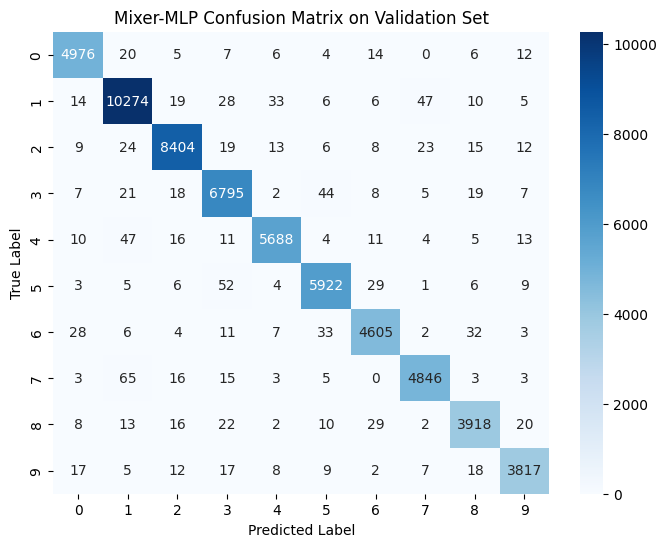

In [ ]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_mlp_val = confusion_matrix(val_labels_mlp, val_preds_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp_val, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Mixer-MLP Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# ----------------------------
# Per-Digit Accuracy
# ----------------------------
print("Per-Digit Accuracy of Mixer-MLP Model on Validation Set:")
print("-" * 50)

for digit in range(10):
    correct = cm_mlp_val[digit, digit]
    total = cm_mlp_val[digit].sum()
    accuracy = (correct / total) * 100 if total > 0 else 0

    print(
        f"Digit {digit}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )


Per-Digit Accuracy of Mixer-MLP Model on Validation Set:
--------------------------------------------------
Digit 0: Accuracy = 98.53% (4976/5050)
Digit 1: Accuracy = 98.39% (10274/10442)
Digit 2: Accuracy = 98.49% (8404/8533)
Digit 3: Accuracy = 98.11% (6795/6926)
Digit 4: Accuracy = 97.92% (5688/5809)
Digit 5: Accuracy = 98.10% (5922/6037)
Digit 6: Accuracy = 97.34% (4605/4731)
Digit 7: Accuracy = 97.72% (4846/4959)
Digit 8: Accuracy = 96.98% (3918/4040)
Digit 9: Accuracy = 97.57% (3817/3912)


##### 5.1.4.4 Mixer-MLP Evaluation on Test Dataset
After selecting the best-performing model based on validation performance, inference was performed on the unseen test dataset to assess the model's generalization capability. Final classification metrics, including accuracy, precision, recall, and F1-score, were computed to provide a comprehensive assessment of the model's effectiveness on previously unseen news articles.

In [ ]:
mlp_test_loader = DataLoader(
    mlp_test_dataset,
    batch_size=best_batch_size_mlp,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

best_model_mlp.eval()

test_preds_mlp = []
test_labels_mlp = []

with torch.no_grad():
    for images, labels in mlp_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model_mlp(images)
        _, predicted = torch.max(outputs, 1)

        test_preds_mlp.extend(predicted.cpu().numpy())
        test_labels_mlp.extend(labels.cpu().numpy())

test_preds_mlp = np.array(test_preds_mlp)
test_labels_mlp = np.array(test_labels_mlp)

test_accuracy_mlp = (test_preds_mlp == test_labels_mlp).mean()
print(f"Mixer-MLP Test Accuracy: {test_accuracy_mlp:.4f}")

Mixer-MLP Test Accuracy: 0.9637


In [ ]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nMixer-MLP Classification Report on Test Set:")
print(classification_report(test_labels_mlp, test_preds_mlp, target_names=class_names))


Mixer-MLP Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      1744
           1       0.98      0.97      0.97      5099
           2       0.98      0.97      0.98      4149
           3       0.95      0.96      0.95      2882
           4       0.97      0.97      0.97      2523
           5       0.96      0.96      0.96      2384
           6       0.95      0.96      0.95      1977
           7       0.97      0.96      0.97      2019
           8       0.95      0.94      0.94      1660
           9       0.94      0.96      0.95      1595

    accuracy                           0.96     26032
   macro avg       0.96      0.96      0.96     26032
weighted avg       0.96      0.96      0.96     26032



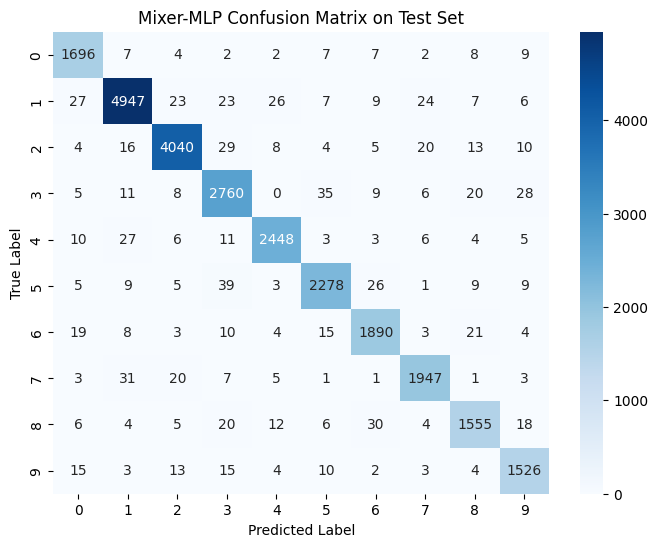

In [ ]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_mlp_test = confusion_matrix(test_labels_mlp, test_preds_mlp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mlp_test, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Mixer-MLP Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix above shows a strong concentration along the diagonal, indicating that the model achieves high classification accuracy across all digits. Most predictions match the true labels, confirming that the model generalizes well to unseen test data.
</br>
</br>
Several digits are classified with particularly high accuracy, as indicated by large diagonal values, examples:
- Digit 1: 4,947 correct predictions (highest)
- Digit 2: 4,040 correct
- Digit 3: 2,760 correct
- Digit 5: 2,278 correct
- Digit 4: 2,448 correct

These results suggest that these digits have distinct visual features, making them easier for the model to identify.
</br>
</br>
Some digits, while still performing well, show slightly higher misclassification rates:
- Digit 8: 1,555 correct, with confusion toward 6 (30 cases)
- Digit 9: 1,526 correct, with confusion toward 0 and 3
- Digit 7: 1,947 correct, with confusion toward 1 (31 cases)
</br>
</br>

The off-diagonal entries highlight specific digit pairs that are more frequently confused:
- 1 ↔ 7:
  - 31 instances where 7 is predicted as 1
  - 24 instances where 1 is predicted as 7
- 3 ↔ 5:
  - 35 instances of 3 → 5
  - 39 instances of 5 → 3
- 8 ↔ 6:
  - 30 instances of 8 → 6
- 4 ↔ 1:
  - 27 instances of 4 → 1

**Below is the accuracy of Mixer-MLP Model on every digit on the test set:**

In [ ]:
# ----------------------------
# Per-Digit Accuracy
# ----------------------------
print("Per-Digit Accuracy of Mixer-MLP Model on Test Set:")
print("-" * 50)

for digit in range(10):
    correct = cm_mlp_test[digit, digit]
    total = cm_mlp_test[digit].sum()
    accuracy = (correct / total) * 100 if total > 0 else 0

    print(
        f"Digit {digit}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )

Per-Digit Accuracy of Mixer-MLP Model on Test Set:
--------------------------------------------------
Digit 0: Accuracy = 97.25% (1696/1744)
Digit 1: Accuracy = 97.02% (4947/5099)
Digit 2: Accuracy = 97.37% (4040/4149)
Digit 3: Accuracy = 95.77% (2760/2882)
Digit 4: Accuracy = 97.03% (2448/2523)
Digit 5: Accuracy = 95.55% (2278/2384)
Digit 6: Accuracy = 95.60% (1890/1977)
Digit 7: Accuracy = 96.43% (1947/2019)
Digit 8: Accuracy = 93.67% (1555/1660)
Digit 9: Accuracy = 95.67% (1526/1595)


### 5.2 Model 2: CNN
A convolutional neural network (CNN) is a type of deep learning model that uses convolutional layers to automatically learn spatial features from images, making it highly effective for tasks like digit classification in datasets such as SVHN.

#### 5.2.1 ResNet50 Architecture
The final CNN model uses a pretrained ResNet50, which leverages residual connections and ImageNet-trained features to effectively learn complex spatial patterns. The model was adapted for SVHN by resizing images to 224×224 and replacing the final layer with a 10-class classifier for digit recognition.

In [ ]:
class SVHNResNet50(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3, freeze_backbone=True):
        super(SVHNResNet50, self).__init__()

        weights = ResNet50_Weights.DEFAULT
        self.backbone = models.resnet50(weights=weights)

        if freeze_backbone:

            # Freeze everything
            for param in self.backbone.parameters():
                param.requires_grad = False

            # Unfreeze only layer4
            for param in self.backbone.layer4.parameters():
                param.requires_grad = True

        else:

            # Train entire network
            for param in self.backbone.parameters():
                param.requires_grad = True

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

#### 5.2.2 ResNet50 Hyperparameters Tuning
Hyperparameter tuning was performed by testing several combinations of learning rate, batch size, dropout rate, and number of epochs. For each configuration, the model was trained and the best checkpoint based on validation accuracy was saved. The saved models were then compared, and the one with the highest validation accuracy was selected for final testing. **For full details on the hyperparameter search and model training, refer to Appendix B.**

In [ ]:
resnet_param_grid = [
    {
        "learning_rate": 0.0001,
        "batch_size": 128,
        "dropout_rate": 0.1,
        "num_epochs": 60,
        "freeze_backbone": False
    },
    {
        "learning_rate": 0.00005,
        "batch_size": 64,
        "dropout_rate": 0.1,
        "num_epochs": 70,
        "freeze_backbone": False
    },
    {
        "learning_rate": 0.00001,
        "batch_size": 64,
        "dropout_rate": 0.0,
        "num_epochs": 80,
        "freeze_backbone": False
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 256,
        "dropout_rate": 0.1,
        "num_epochs": 50,
        "freeze_backbone": False
    },
    {
        "learning_rate": 0.0002,
        "batch_size": 128,
        "dropout_rate": 0.1,
        "num_epochs": 50,
        "freeze_backbone": False
    },
    {
        "learning_rate": 0.0001,
        "batch_size": 128,
        "dropout_rate": 0.2,
        "num_epochs": 40,
        "freeze_backbone": True
    }

]

resnet_experiment_results = []
resnet_all_histories = {}

In [ ]:
# ----------------------------
# Global resume tracking for ResNet50
# ----------------------------
resnet_total_experiments = len(resnet_param_grid)
resnet_resume_experiment = 1
resnet_global_checkpoint = SAVED_MODELS_DIR / "resnet50_hparam_search_state.pth"

resnet_all_done = False

if resnet_global_checkpoint.exists():
    print("Global ResNet50 experiment checkpoint found...")
    # Fix: Add weights_only=False to torch.load as the checkpoint contains pathlib.PosixPath objects.
    resnet_global_state = torch.load(resnet_global_checkpoint, map_location=device, weights_only=False)

    saved_idx = resnet_global_state.get("experiment_idx", 1)
    resnet_experiment_results = resnet_global_state.get("experiment_results", [])
    resnet_all_histories = resnet_global_state.get("all_histories", {})

    if saved_idx > resnet_total_experiments:
        resnet_all_done = True
        resnet_resume_experiment = resnet_total_experiments + 1
        print(f"All {resnet_total_experiments} ResNet50 experiments are already completed.")
    else:
        resnet_resume_experiment = max(1, saved_idx)
        print(f"Resuming from ResNet50 experiment {resnet_resume_experiment} of {resnet_total_experiments}")
else:
    print("No global ResNet50 experiment checkpoint found.")
    resnet_experiment_results = []
    resnet_all_histories = {}

Global ResNet50 experiment checkpoint found...
All 6 ResNet50 experiments are already completed.


In [ ]:
use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

In [ ]:
# =====================================================================================
# RESNET50 HYPERPARAMETER SEARCH
# =====================================================================================
if resnet_all_done:
    print("Skipping ResNet50 hyperparameter search.")
else:
  for exp_idx, params in enumerate(resnet_param_grid, start=1):

      if exp_idx < resnet_resume_experiment:
          print(f"Skipping completed ResNet50 experiment {exp_idx}")
          continue

      print("=" * 100)
      print(f"ResNet50 Experiment {exp_idx}/{len(resnet_param_grid)}")
      print("Parameters:", params)
      print("=" * 100)

      resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=params["batch_size"], shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
      resnet_val_loader = DataLoader(resnet_val_dataset, batch_size=params["batch_size"], shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

      resnet_model = SVHNResNet50(
          num_classes=10,
          dropout_rate=params["dropout_rate"],
          freeze_backbone=params["freeze_backbone"]
      ).to(device)

      resnet_criterion = nn.CrossEntropyLoss()

      resnet_optimizer = optim.AdamW(
          filter(lambda p: p.requires_grad, resnet_model.parameters()),
          lr=params["learning_rate"],
          weight_decay=1e-4
      )

      resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
          resnet_optimizer,
          mode="max",
          factor=0.5,
          patience=2
      )

      best_val_acc = 0.0
      best_val_loss = float("inf")
      best_epoch = 0
      best_model_state_dict = None

      patience = 5
      epochs_without_improvement = 0

      train_losses = []
      val_losses = []
      train_accuracies = []
      val_accuracies = []

      lr_str = str(params["learning_rate"]).replace(".", "_")
      drop_str = str(params["dropout_rate"]).replace(".", "_")
      freeze_str = "frozen" if params["freeze_backbone"] else "unfrozen"

      checkpoint_name = (
          SAVED_MODELS_DIR / f"resnet50_exp{exp_idx}_"
          f"lr{lr_str}_bs{params['batch_size']}_drop{drop_str}_{freeze_str}.pth"
      )

      start_epoch = 0

      if os.path.exists(checkpoint_name):
          print("ResNet50 checkpoint found. Resuming training...")

          checkpoint = torch.load(checkpoint_name, map_location=device)

          resnet_model.load_state_dict(checkpoint["latest_model_state_dict"])
          resnet_optimizer.load_state_dict(checkpoint["latest_optimizer_state_dict"])

          start_epoch = checkpoint.get("epoch", 0)
          best_val_acc = checkpoint.get("best_val_acc", 0.0)
          best_val_loss = checkpoint.get("best_val_loss", float("inf"))
          best_epoch = checkpoint.get("best_epoch", 0)
          best_model_state_dict = checkpoint.get("best_model_state_dict", None)
          epochs_without_improvement = checkpoint.get("epochs_without_improvement", 0)

          train_losses = checkpoint.get("train_losses", [])
          val_losses = checkpoint.get("val_losses", [])
          train_accuracies = checkpoint.get("train_accuracies", [])
          val_accuracies = checkpoint.get("val_accuracies", [])

          print(f"Resuming ResNet50 from epoch {start_epoch}")
      else:
          print("No ResNet50 experiment checkpoint found. Starting fresh training.")

      start_time = time.time()

      for epoch in range(start_epoch, params["num_epochs"]):
          resnet_model.train()

          running_loss = 0.0
          correct = 0
          total = 0

          epoch_start = time.time()

          for images, labels in resnet_train_loader:
              images = images.to(device)
              labels = labels.to(device)

              resnet_optimizer.zero_grad()

              with torch.cuda.amp.autocast(enabled=use_amp):
                  outputs = resnet_model(images)
                  loss = resnet_criterion(outputs, labels)

              scaler.scale(loss).backward()
              scaler.unscale_(resnet_optimizer)
              torch.nn.utils.clip_grad_norm_(resnet_model.parameters(), max_norm=1.0)
              scaler.step(resnet_optimizer)
              scaler.update()

              running_loss += loss.item() * images.size(0)

              _, predicted = torch.max(outputs, 1)
              total += labels.size(0)
              correct += (predicted == labels).sum().item()

          epoch_train_loss = running_loss / total
          epoch_train_acc = correct / total

          train_losses.append(epoch_train_loss)
          train_accuracies.append(epoch_train_acc)

          resnet_model.eval()

          val_running_loss = 0.0
          val_correct = 0
          val_total = 0

          with torch.no_grad():
              for images, labels in resnet_val_loader:
                  images = images.to(device)
                  labels = labels.to(device)

                  with torch.cuda.amp.autocast(enabled=use_amp):
                      outputs = resnet_model(images)
                      loss = resnet_criterion(outputs, labels)

                  val_running_loss += loss.item() * images.size(0)

                  _, predicted = torch.max(outputs, 1)
                  val_total += labels.size(0)
                  val_correct += (predicted == labels).sum().item()

          epoch_val_loss = val_running_loss / val_total
          epoch_val_acc = val_correct / val_total

          val_losses.append(epoch_val_loss)
          val_accuracies.append(epoch_val_acc)

          resnet_scheduler.step(epoch_val_acc)

          epoch_duration = time.time() - epoch_start

          print(
              f"Epoch [{epoch+1}/{params['num_epochs']}] "
              f"Train Loss: {epoch_train_loss:.4f}, "
              f"Train Accuracy: {epoch_train_acc:.4f}, "
              f"Validation Loss: {epoch_val_loss:.4f}, "
              f"Validation Accuracy: {epoch_val_acc:.4f}, "
              f"Epoch Duration: {epoch_duration:.2f} seconds"
          )

          if epoch_val_acc > best_val_acc:
              best_val_acc = epoch_val_acc
              best_val_loss = epoch_val_loss
              best_epoch = epoch + 1
              epochs_without_improvement = 0

              best_model_state_dict = {
                  k: v.detach().cpu().clone()
                  for k, v in resnet_model.state_dict().items()
              }

              print("Best ResNet50 model improved.")
          else:
              epochs_without_improvement += 1

          total_elapsed = time.time() - start_time

          safe_torch_save({
              "epoch": epoch + 1,
              "experiment_idx": exp_idx,
              "latest_model_state_dict": resnet_model.state_dict(),
              "latest_optimizer_state_dict": resnet_optimizer.state_dict(),
              "best_model_state_dict": best_model_state_dict,
              "best_val_acc": best_val_acc,
              "best_val_loss": best_val_loss,
              "best_epoch": best_epoch,
              "val_acc": epoch_val_acc,
              "val_loss": epoch_val_loss,
              "epochs_without_improvement": epochs_without_improvement,
              "params": params,
              "total_training_time_sec": total_elapsed,
              "train_losses": train_losses,
              "val_losses": val_losses,
              "train_accuracies": train_accuracies,
              "val_accuracies": val_accuracies
          }, checkpoint_name)

          if epochs_without_improvement >= patience:
              print(f"Early stopping at epoch {epoch+1}")
              break

      resnet_experiment_results = [r for r in resnet_experiment_results if r["experiment"] != exp_idx]
      resnet_experiment_results.append({
          "experiment": exp_idx,
          "learning_rate": params["learning_rate"],
          "batch_size": params["batch_size"],
          "dropout_rate": params["dropout_rate"],
          "num_epochs": params["num_epochs"],
          "freeze_backbone": params["freeze_backbone"],
          "best_val_acc": best_val_acc,
          "best_val_loss": best_val_loss,
          "best_epoch": best_epoch,
          "checkpoint": checkpoint_name
      })

      resnet_all_histories[checkpoint_name] = {
          "train_losses": train_losses,
          "val_losses": val_losses,
          "train_accuracies": train_accuracies,
          "val_accuracies": val_accuracies
      }

      safe_torch_save({
          "experiment_idx": exp_idx + 1,
          "experiment_results": resnet_experiment_results,
          "all_histories": resnet_all_histories
      }, resnet_global_checkpoint)

      gc.collect()
      if torch.cuda.is_available():
          torch.cuda.empty_cache()

  resnet_results_df = pd.DataFrame(resnet_experiment_results)
  resnet_results_df = resnet_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)

  print("\nResNet50 Tuning Results:")
  print(resnet_results_df)

Skipping ResNet50 hyperparameter search.


#### 5.2.3 ResNet50 Evaluation
Compare all saved models based on validation accuracy/loss and selecting the best-performing model.

In [ ]:
resnet_results_df = pd.DataFrame(resnet_experiment_results)
resnet_results_df = resnet_results_df.sort_values(by="best_val_acc", ascending=False).reset_index(drop=True)

print("\nResNet50 Hyperparameter Tuning Results:")
print(resnet_results_df)

resnet_results_df.to_csv(SAVED_MODELS_DIR / "resnet50_hyperparameter_results.csv", index=False)
print(f"Saved tuning results to {SAVED_MODELS_DIR}/resnet50_hyperparameter_results.csv")


ResNet50 Hyperparameter Tuning Results:
   experiment  learning_rate  batch_size  dropout_rate  num_epochs  \
0           1        0.00010         128           0.1          60   
1           5        0.00020         128           0.1          50   
2           2        0.00005          64           0.1          70   
3           4        0.00010         256           0.1          50   
4           3        0.00001          64           0.0          80   
5           6        0.00010         128           0.2          40   

   freeze_backbone  best_val_acc  best_val_loss  best_epoch  \
0            False      0.988600       0.051228           8   
1            False      0.988253       0.049822          11   
2            False      0.987905       0.065474          11   
3            False      0.987839       0.050237           6   
4            False      0.986747       0.081947          14   
5             True      0.985324       0.105475          38   

                          

##### 5.2.3.1 Load Best ResNet50 Model for Evaluation
Load the saved `.pth` checkpoint and set model to evaluation mode.

In [ ]:
best_resnet_checkpoint_path = PROJECT_ROOT / resnet_results_df.iloc[0]["checkpoint"]
print("Best ResNet50 checkpoint selected:", best_resnet_checkpoint_path)


Best ResNet50 checkpoint selected: /content/drive/MyDrive/tafe/src/svhn/saved_models/resnet50_exp1_lr0_0001_bs128_drop0_1_unfrozen.pth


In [ ]:
%%capture

resnet_checkpoint = torch.load(best_resnet_checkpoint_path, map_location=device)
best_resnet_params = resnet_checkpoint["params"]

best_resnet_model = SVHNResNet50(
    num_classes=10,
    dropout_rate=best_resnet_params["dropout_rate"],
    freeze_backbone=best_resnet_params["freeze_backbone"]
).to(device)

if resnet_checkpoint["best_model_state_dict"] is None:
    raise ValueError("Best ResNet50 model state dict is None. Training may not have completed properly.")

best_resnet_model.load_state_dict(resnet_checkpoint["best_model_state_dict"])
best_resnet_model.eval()

##### 5.2.3.2 Training History Analysis of Best ResNet50 Model
These plots show the best model’s training/validation loss accuracy curves.

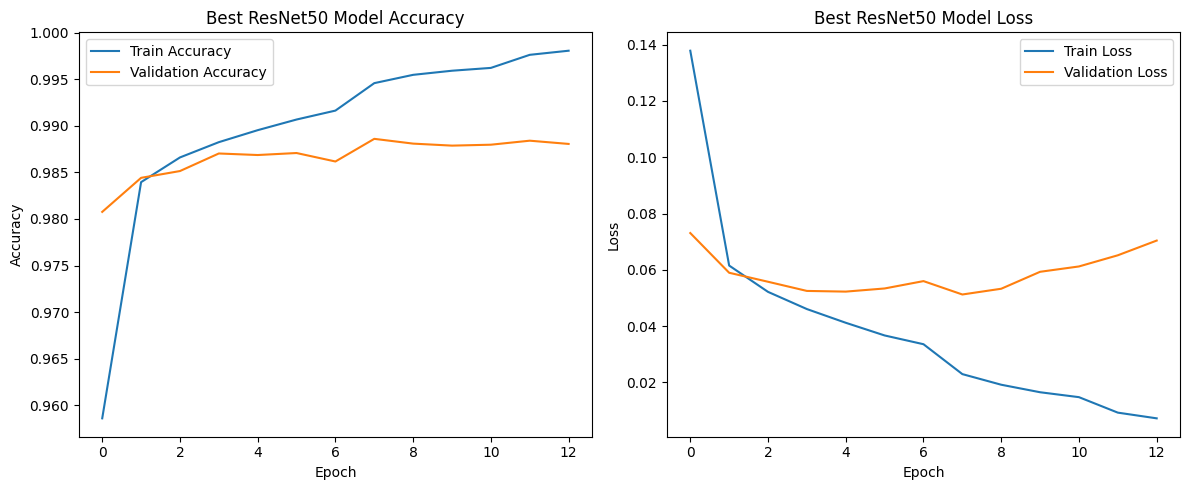

In [ ]:
best_resnet_history = resnet_all_histories[resnet_results_df.iloc[0]["checkpoint"]]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(best_resnet_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_resnet_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best ResNet50 Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_resnet_history["train_losses"], label="Train Loss")
plt.plot(best_resnet_history["val_losses"], label="Validation Loss")
plt.title("Best ResNet50 Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

##### 5.2.3.3 ResNet50 Evaluation on Validation Data
Using relevant metrics such as precision, recall, F1-score, and accuracy and Confusion Matrix visualization.

In [ ]:
best_batch_size_resnet = best_resnet_params["batch_size"]

resnet_val_loader = DataLoader(
    resnet_val_dataset,
    batch_size=best_batch_size_resnet,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_preds_resnet = []
val_labels_resnet = []

best_resnet_model.eval()

with torch.no_grad():
    for images, labels in resnet_val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        val_preds_resnet.extend(predicted.cpu().numpy())
        val_labels_resnet.extend(labels.cpu().numpy())

val_preds_resnet = np.array(val_preds_resnet)
val_labels_resnet = np.array(val_labels_resnet)

val_accuracy_resnet = (val_preds_resnet == val_labels_resnet).mean()
print(f"ResNet50 Validation Accuracy: {val_accuracy_resnet:.4f}")

ResNet50 Validation Accuracy: 0.9886


In [ ]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nResNet50 Classification Report on Validation Set:")
print(classification_report(val_labels_resnet, val_preds_resnet, target_names=class_names))


ResNet50 Classification Report on Validation Set:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5050
           1       0.99      0.99      0.99     10442
           2       0.99      0.99      0.99      8533
           3       0.99      0.99      0.99      6926
           4       0.99      0.99      0.99      5809
           5       0.99      0.99      0.99      6037
           6       0.99      0.98      0.99      4731
           7       0.99      0.99      0.99      4959
           8       0.98      0.99      0.98      4040
           9       0.99      0.99      0.99      3912

    accuracy                           0.99     60439
   macro avg       0.99      0.99      0.99     60439
weighted avg       0.99      0.99      0.99     60439



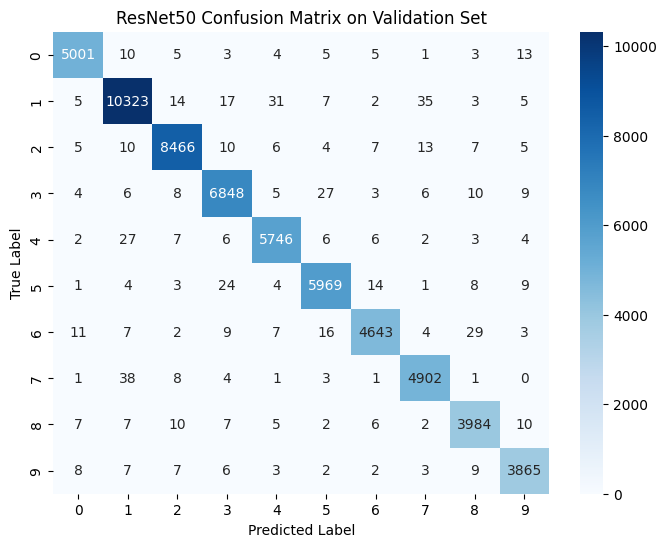

In [ ]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_resnet_val = confusion_matrix(val_labels_resnet, val_preds_resnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet_val, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("ResNet50 Confusion Matrix on Validation Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
# ----------------------------
# Per-Digit Accuracy
# ----------------------------
print("Per-Digit Accuracy of ResNet50 Model on Validation Set:")
print("-" * 50)

for digit in range(10):
    correct = cm_resnet_val[digit, digit]
    total = cm_resnet_val[digit].sum()
    accuracy = (correct / total) * 100 if total > 0 else 0

    print(
        f"Digit {digit}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )


Per-Digit Accuracy of ResNet50 Model on Validation Set:
--------------------------------------------------
Digit 0: Accuracy = 99.03% (5001/5050)
Digit 1: Accuracy = 98.86% (10323/10442)
Digit 2: Accuracy = 99.21% (8466/8533)
Digit 3: Accuracy = 98.87% (6848/6926)
Digit 4: Accuracy = 98.92% (5746/5809)
Digit 5: Accuracy = 98.87% (5969/6037)
Digit 6: Accuracy = 98.14% (4643/4731)
Digit 7: Accuracy = 98.85% (4902/4959)
Digit 8: Accuracy = 98.61% (3984/4040)
Digit 9: Accuracy = 98.80% (3865/3912)


##### 5.2.3.4 ResNet50 Evaluation on Test Dataset
After selecting the best-performing model based on validation performance, inference was performed on the unseen test dataset to assess the model's generalization capability. Final classification metrics, including accuracy, precision, recall, and F1-score, were computed to provide a comprehensive assessment of the model's effectiveness on previously unseen news articles.

In [ ]:
resnet_test_loader = DataLoader(resnet_test_dataset, batch_size=best_batch_size_resnet, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

test_preds_resnet = []
test_labels_resnet = []

best_resnet_model.eval()

with torch.no_grad():
    for images, labels in resnet_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_resnet_model(images)
        _, predicted = torch.max(outputs, 1)

        test_preds_resnet.extend(predicted.cpu().numpy())
        test_labels_resnet.extend(labels.cpu().numpy())

test_preds_resnet = np.array(test_preds_resnet)
test_labels_resnet = np.array(test_labels_resnet)

test_accuracy_resnet = (test_preds_resnet == test_labels_resnet).mean()
print(f"ResNet50 Test Accuracy: {test_accuracy_resnet:.4f}")

ResNet50 Test Accuracy: 0.9811


In [ ]:
# ----------------------------
# Classification Report
# ----------------------------
print("\nResNet50 Classification Report on Test Set:")
print(classification_report(test_labels_resnet, test_preds_resnet, target_names=class_names))


ResNet50 Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1744
           1       0.98      0.98      0.98      5099
           2       0.99      0.99      0.99      4149
           3       0.98      0.98      0.98      2882
           4       0.99      0.99      0.99      2523
           5       0.98      0.97      0.98      2384
           6       0.98      0.98      0.98      1977
           7       0.98      0.98      0.98      2019
           8       0.97      0.98      0.98      1660
           9       0.97      0.98      0.98      1595

    accuracy                           0.98     26032
   macro avg       0.98      0.98      0.98     26032
weighted avg       0.98      0.98      0.98     26032



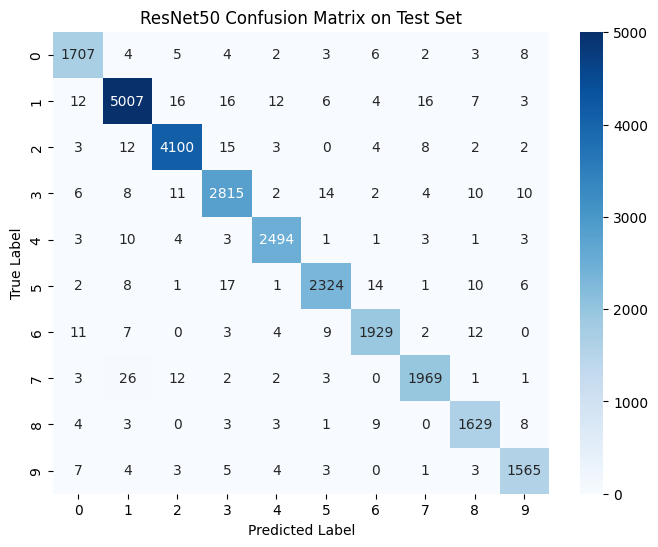

In [ ]:
# ----------------------------
# Confusion Matrix
# ----------------------------
cm_resnet_test = confusion_matrix(test_labels_resnet, test_preds_resnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_resnet_test, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("ResNet50 Confusion Matrix on Test Set")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

The confusion matrix above illustrates the performance of the ResNet50 model on the SVHN test set. Most digits are correctly classified, demonstrating that the model generalizes effectively to unseen data.
</br>
</br>
Several digits are classified particularly well, with high numbers of correct predictions:
- Digit 1: 5007 correct predictions (highest)
- Digit 2: 4100 correct
- Digit 3: 2815 correct
- Digit 4: 2494 correct
- Digit 5: 2324 correct

This indicates that these digits have distinct visual characteristics, making them easier for the model to recognize.
</br>
</br>
Some digits show slightly higher misclassification rates:
- Digit 8: 1629 correct, with confusion toward 6 and 9
- Digit 9: 1565 correct, with some confusion toward 0 and 3
- Digit 7: 1969 correct, with confusion toward 1 (26 cases)
</br>
</br>

The off-diagonal values reveal common confusion between visually similar digits:
- 1 ↔ 7:
  - 26 instances of 7 → 1
  - 16 instances of 1 → 7
- 3 ↔ 5:
  - 14 instances of 3 → 5
  - 17 instances of 5 → 3
- 8 ↔ 6:
  - 9 instances of 8 → 6
- 4 ↔ 1:
  - 10 instances of 4 → 1

**Below is the accuracy of ResNet50 Model on every digit on the test set:**

In [ ]:
# ----------------------------
# Per-Digit Accuracy
# ----------------------------
print("Per-Digit Accuracy of ResNet50 Model on Test Set:")
print("-" * 50)

for digit in range(10):
    correct = cm_resnet_test[digit, digit]
    total = cm_resnet_test[digit].sum()
    accuracy = (correct / total) * 100 if total > 0 else 0

    print(
        f"Digit {digit}: Accuracy = "
        f"{accuracy:.2f}% "
        f"({correct}/{total})"
    )


Per-Digit Accuracy of ResNet50 Model on Test Set:
--------------------------------------------------
Digit 0: Accuracy = 97.88% (1707/1744)
Digit 1: Accuracy = 98.20% (5007/5099)
Digit 2: Accuracy = 98.82% (4100/4149)
Digit 3: Accuracy = 97.68% (2815/2882)
Digit 4: Accuracy = 98.85% (2494/2523)
Digit 5: Accuracy = 97.48% (2324/2384)
Digit 6: Accuracy = 97.57% (1929/1977)
Digit 7: Accuracy = 97.52% (1969/2019)
Digit 8: Accuracy = 98.13% (1629/1660)
Digit 9: Accuracy = 98.12% (1565/1595)


# 6. Model Evaluation and Performance Results
---

**Comparison of Mixer-MLP vs ResNet50 Accuracy Plots.**  
The two plots show the training and validation accuracy over epochs for the best-performing Mixer-MLP and ResNet50 models on the SVHN dataset.

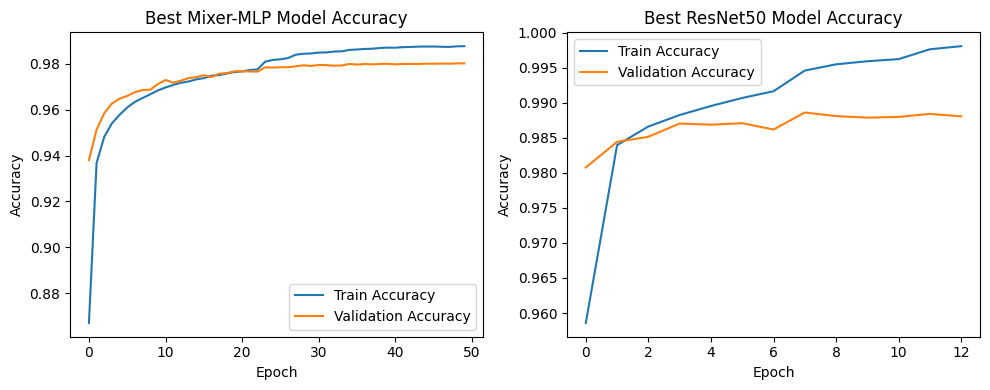

In [ ]:
# -------------------------------------
# Mixer-MLP vs ResNet50 Model Accuracy Trend
# -------------------------------------
best_mlp_history = mlp_all_histories[mlp_results_df.iloc[0]["checkpoint"]]
best_resnet_history = resnet_all_histories[resnet_results_df.iloc[0]["checkpoint"]]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(best_mlp_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_mlp_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best Mixer-MLP Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_resnet_history["train_accuracies"], label="Train Accuracy")
plt.plot(best_resnet_history["val_accuracies"], label="Validation Accuracy")
plt.title("Best ResNet50 Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

From the above plots, it can be seen how much faster ResNet50's learning speed is compared to Mixer-MLP. Thanks to transfer learning (ImageNet), ResNet50 only needs a fewer epochs to learn, where in its final training accuracy, it came very close to reaching 100%.
</br>
</br>
The final validation accuracy for Mixer-MLP was about ~98%, while ResNet50 is about ~98.8-99%. This means, the latter has better feature extraction.
</br>
</br>
Mixer-MLP has shown a smaller gap on the train-validation accuracy, which means that it is not prone to overfitting hence more stable compared to ResNet50.


**Comparison of Mixer-MLP vs ResNet50 Loss Plots.**  
The two plots show the training and validation loss over epochs for the best-performing Mixer-MLP and ResNet50 models on the SVHN dataset.

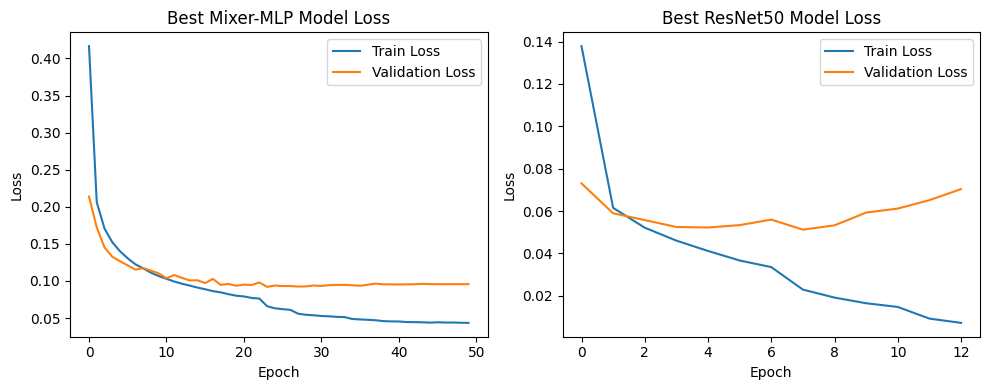

In [ ]:
# -------------------------------------
# Mixer-MLP vs ResNet50 Model Loss Trend
# -------------------------------------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(best_mlp_history["train_losses"], label="Train Loss")
plt.plot(best_mlp_history["val_losses"], label="Validation Loss")
plt.title("Best Mixer-MLP Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_resnet_history["train_losses"], label="Train Loss")
plt.plot(best_resnet_history["val_losses"], label="Validation Loss")
plt.title("Best ResNet50 Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

The loss curves of the Mixer-MLP model demonstrate stable and consistent learning throughout training. Both training and validation loss decrease smoothly over time, with the training loss steadily dropping from approximately 0.41 to around 0.04 and the validation loss from about 0.21 to roughly 0.09. The relatively small gap between the two curves indicates good generalization, as the model performs similarly on both seen and unseen data. Additionally, the absence of sharp fluctuations or increases in validation loss suggests that the model does not suffer from significant overfitting.
</br>
</br>
The loss curves of the ResNet50 model indicate rapid learning and strong fitting to the training data, but also reveal signs of overfitting during later epochs. The training loss decreases sharply from approximately 0.14 to below 0.01 within a few epochs, demonstrating the model's ability to quickly learn discriminative features due to transfer learning. The validation loss initially decreases from around 0.07 to about 0.05, showing early improvement in generalization; however, it begins to gradually increase after around 5-6 epochs. This widening gap between training and validation loss suggests that the model starts to overfit, as it continues to optimize for the training data while performance on unseen data deteriorates slightly.

**Per-Digit Accuracy Comparison.**  
This comparison shows how accurately each model classified each digit from 0 to 9 on the test set. For each digit, the table reports:
- the accuracy percentage
- the number of correct predictions
- the total number of test samples for that digit

The `Cmp` column indicates which model performed better:
- < means ResNet50 performed better than Mixer-MLP
- \> would mean Mixer-MLP performed better
- = would mean both performed the same

In [ ]:
# -------------------------------------
# Mixer-MLP vs ResNet50 Per-Digit Accuracy Comparison
# -------------------------------------
print("Per-Digit Accuracy Comparison on Test Set: Mixer-MLP vs ResNet50")
print("-" * 90)
print(f"{'Digit':<8}{'Mixer-MLP':<28}{'Cmp':<6}{'ResNet50':<28}")
print("-" * 90)

for digit in range(10):
    # Mixer-MLP
    mlp_correct = cm_mlp_test[digit, digit]
    mlp_total = cm_mlp_test[digit].sum()
    mlp_acc = (mlp_correct / mlp_total) * 100 if mlp_total > 0 else 0

    # ResNet50
    cnn_correct = cm_resnet_test[digit, digit]
    cnn_total = cm_resnet_test[digit].sum()
    cnn_acc = (cnn_correct / cnn_total) * 100 if cnn_total > 0 else 0

    # Comparison symbol
    if mlp_acc > cnn_acc:
        cmp_symbol = ">"
    elif mlp_acc < cnn_acc:
        cmp_symbol = "<"
    else:
        cmp_symbol = "="

    print(
        f"{digit:<8}"
        f"{f'{mlp_acc:.2f}% ({mlp_correct}/{mlp_total})':<28}"
        f"{cmp_symbol:^6}"
        f"{f'{cnn_acc:.2f}% ({cnn_correct}/{cnn_total})':<28}"
    )

Per-Digit Accuracy Comparison on Test Set: Mixer-MLP vs ResNet50
------------------------------------------------------------------------------------------
Digit   Mixer-MLP                   Cmp   ResNet50                    
------------------------------------------------------------------------------------------
0       97.25% (1696/1744)            <   97.88% (1707/1744)          
1       97.02% (4947/5099)            <   98.20% (5007/5099)          
2       97.37% (4040/4149)            <   98.82% (4100/4149)          
3       95.77% (2760/2882)            <   97.68% (2815/2882)          
4       97.03% (2448/2523)            <   98.85% (2494/2523)          
5       95.55% (2278/2384)            <   97.48% (2324/2384)          
6       95.60% (1890/1977)            <   97.57% (1929/1977)          
7       96.43% (1947/2019)            <   97.52% (1969/2019)          
8       93.67% (1555/1660)            <   98.13% (1629/1660)          
9       95.67% (1526/1595)            <   9

From above table, ResNet50 clearly outperformed Mixer-MLP on every digit and achieved higher accuracy than Mixer-MLP for all 10 digit classes. This indicates that ResNet50 is consistently better at recognizing SVHN digits.
</br>
</br>
Although ResNet50 was better across all classes, the Mixer-MLP still achieved high accuracy, mostly above 95%, and above 97% for some digits such as 0, 1, 2, and 4. This suggests that Mixer-MLP is a competitive model, but not as strong as ResNet50 for this image classification task.
</br>
</br>
The biggest difference appears for:
- Digit 8:
  - Mixer-MLP: 93.67%
  - ResNet50: 98.13%
  - Difference: 4.46 percentage points
- Digit 9:
  - Mixer-MLP: 95.67%
  - ResNet50: 98.12%
  - Difference: 2.45 percentage points  

This suggests that ResNet50 is much better at handling more visually challenging digits, especially those with shapes that may resemble other classes.
</br>
</br>
ResNet50 exceeds 97.5% accuracy on every digit, and reaches nearly 99% on several classes, which indicates that the CNN-based model is highly effective at capturing the spatial patterns needed for robust digit recognition.
</br>
</br>
Mixer-MLP struggles more on visually complex digits. Digits 3,4,6,8,9 are more difficult to recognize because of shape similarity, background clutter, blur, or variation in real-world house number images.

# 7. Discussion of Model Limitations or Constraints
---

Despite achieving strong performance, both the Mixer-MLP and ResNet50 models have several limitations. For the Mixer-MLP, its primary constraint lies in its limited ability to capture fine-grained spatial features, as it relies on fully connected layers rather than convolution. As a result, it performs slightly worse on visually complex digits, particularly those with similar shapes such as 8 and 9. Additionally, the model requires more training epochs to converge, making it less efficient in terms of training time.
</br>
</br>
On the other hand, while ResNet50 achieves higher overall accuracy, it exhibits signs of overfitting, as seen from the divergence between training and validation loss. This suggests that the model may memorize training data patterns rather than fully generalizing to unseen samples. Furthermore, ResNet50 is computationally expensive due to its deep architecture and large input size (224×224), requiring greater memory and processing resources compared to Mixer-MLP.
</br>
</br>
Another limitation shared by both models is the difficulty in distinguishing visually similar digits, which leads to consistent misclassification patterns across classes. In addition, resizing SVHN images from 32×32 to 224×224 for ResNet50 may introduce interpolation artifacts or redundant information, which could affect learning efficiency.
</br>
</br>
Overall, while ResNet50 provides superior accuracy, it comes at the cost of higher computational complexity and a greater risk of overfitting, whereas Mixer-MLP offers a more stable and lightweight alternative but with slightly lower performance.

# 8. Potential Business Impact and Real-World Applications
---

The SVHN digit classification models, particularly ResNet50 and Mixer-MLP, have significant potential for real-world deployment across a range of business applications. One key application is in **automated address recognition systems**, where accurately detecting and classifying house numbers from street images can improve services such as navigation, logistics, and delivery routing. Companies in e-commerce and courier services can leverage such models to enhance delivery efficiency by automatically identifying addresses from images.
</br>
</br>
In addition, these models can be applied in smart city infrastructure, **such as traffic monitoring systems**, where recognizing numeric information from road signs, vehicle plates, or building numbers can support urban planning and public safety. Financial institutions may also benefit from similar digit recognition systems in **document processing**, such as reading numeric information from forms, invoices, or checks, improving automation and reducing manual data entry errors.
</br>
</br>
From a broader perspective, the strong performance of ResNet50 highlights its suitability for high-accuracy, production-level systems, where reliability is critical, despite higher computational cost. In contrast, Mixer-MLP offers a more lightweight alternative, which may be beneficial for deployment in resource-constrained environments, such as mobile or edge devices, where computational efficiency and stability are important.
</br>
</br>
Overall, the ability to accurately recognize digits in real-world images enables scalable automation across industries, leading to improved operational efficiency, reduced costs, and enhanced user experience.

# 9. Future Improvements / Future Work
---

Several enhancements can be explored to further improve the performance and robustness of the models used for SVHN digit classification. First, more advanced regularization techniques such as dropout tuning, weight decay optimization, or data augmentation strategies could help reduce overfitting, particularly for the ResNet50 model.
</br>
</br>
Another potential improvement is experimenting with different model architectures, such as more recent CNN variants (e.g., EfficientNet) or hybrid architectures that combine convolutional layers with attention mechanisms. For the Mixer-MLP model, incorporating **patch-based improvements or hybrid CNN-MLP designs** could enhance its ability to capture spatial features more effectively.
</br>
</br>
Further gains may also be achieved by using **larger or more diverse training data**, or applying advanced preprocessing techniques such as better normalization, contrast enhancement, or noise reduction. Hyperparameter optimization using methods like **grid search or Bayesian optimization** could also help identify more optimal configurations.
</br>
</br>
Finally, future work could focus on **deployment considerations**, such as model compression, pruning, or quantization, to enable efficient inference on real-world systems, including mobile or edge devices. These improvements would enhance both the accuracy and practical usability of the models in real-world applications.

# 10. Conclusion
---

This project evaluated the effectiveness of two deep learning approaches—Mixer-MLP and ResNet50—for SVHN digit classification. The results show that both models are capable of achieving high performance, but they differ in learning behavior, efficiency, and overall effectiveness.
</br>
</br>
The **Mixer-MLP model** demonstrated **stable and reliable training**, with smooth convergence and minimal overfitting. However, it required more epochs to reach optimal performance and showed slightly lower accuracy, particularly on more visually complex digits.
</br>
</br>
In contrast, the **ResNet50 model** leveraged convolutional operations and transfer learning to achieve **faster convergence, lower loss, and consistently higher accuracy**. It outperformed Mixer-MLP across all digit classes and achieved a superior test accuracy of **98.11% compared to 96.37%**, confirming its effectiveness in capturing fine-grained spatial features such as edges and digit structures. However, it also showed signs of overfitting, indicating the need for careful regularization and early stopping.
</br>
</br>
Overall, the findings suggest that **ResNet50 is the better choice for image recognition tasks**, particularly for real-world datasets like SVHN, due to its ability to learn rich hierarchical spatial features and deliver higher classification accuracy. Meanwhile, Mixer-MLP remains a strong alternative when model simplicity, stability, or computational efficiency is a priority.

# Appendix
---

### A. ResNet50 Single-Sample Diagnostic Analysis

This section performs a diagnostic analysis on a single sample to understand how the ResNet50 model processes and learns from input data. It visualizes the original image alongside intermediate feature maps to illustrate how meaningful patterns are extracted across different layers. The transformation from extracted features to final predictions is examined through logits, loss, and gradients. In summary, this analysis offers a clearer view of the model’s decision-making process and how its parameters are updated during training.

In [ ]:
%%capture
def denormalize_image(img_tensor, mean, std):
    img = img_tensor.detach().cpu().clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    img = img.clamp(0, 1)
    return img

def show_input_image_resnet(img_tensor, title, mean=None, std=None):
    if img_tensor.dim() == 4:
        img_tensor = img_tensor.squeeze(0)

    if mean is not None and std is not None:
        img_tensor = denormalize_image(img_tensor, mean, std)

    img = img_tensor.permute(1, 2, 0).detach().cpu().numpy()

    plt.figure(figsize=(2, 2))
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_feature_maps_resnet(feature_tensor, layer_name, max_maps=8):
    feature_maps = feature_tensor.squeeze(0).detach().cpu()

    num_maps = min(feature_maps.shape[0], max_maps)
    cols = min(4, num_maps)
    rows = math.ceil(num_maps / cols)

    plt.figure(figsize=(4 * cols, 3 * rows))

    for i in range(num_maps):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(feature_maps[i], cmap="gray")
        plt.title(f"{layer_name}\nMap {i + 1}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def print_kernel_weights_resnet(layer, layer_name, max_filters=3):
    weights = layer.weight.data.detach().cpu()
    print(f"\n{layer_name} kernel weights")
    print(f"Weight shape: {weights.shape}")

    num_filters = min(weights.shape[0], max_filters)

    for filter_idx in range(num_filters):
        print(f"\n{layer_name} Filter {filter_idx + 1}")
        kernel = weights[filter_idx].mean(dim=0)
        print(kernel)

def print_kernel_gradients_resnet(layer, layer_name, max_filters=3):
    if layer.weight.grad is None:
        print(f"\nNo gradients available yet for {layer_name}")
        return

    gradients = layer.weight.grad.detach().cpu()
    print(f"\nGradient of loss with respect to {layer_name} weights")
    print(f"Gradient shape: {gradients.shape}")

    num_filters = min(gradients.shape[0], max_filters)

    for filter_idx in range(num_filters):
        print(f"\n{layer_name} Filter {filter_idx + 1} Gradient")
        grad = gradients[filter_idx].mean(dim=0)
        print(grad)

def print_updated_kernel_weights_resnet(layer, layer_name, max_filters=3):
    weights = layer.weight.data.detach().cpu()
    print(f"\nUpdated {layer_name} kernel weights")
    print(f"Weight shape: {weights.shape}")

    num_filters = min(weights.shape[0], max_filters)

    for filter_idx in range(num_filters):
        print(f"\nUpdated {layer_name} Filter {filter_idx + 1}")
        kernel = weights[filter_idx].mean(dim=0)
        print(kernel)

def get_resnet_intermediate_outputs(model, x):
    activations = {}
    hooks = []

    def save_output(name):
        def hook(module, input, output):
            activations[name] = output
        return hook

    layer_map = {
        "conv1": model.backbone.conv1,
        "layer1": model.backbone.layer1,
        "layer2": model.backbone.layer2,
        "layer3": model.backbone.layer3,
        "layer4": model.backbone.layer4,
        "avgpool": model.backbone.avgpool,
    }

    for name, layer in layer_map.items():
        hooks.append(layer.register_forward_hook(save_output(name)))

    logits = model(x)

    for h in hooks:
        h.remove()

    return logits, activations

def print_logits_equation_resnet(model, pooled_features, logits, max_classes=2):
    final_linear = model.backbone.fc[1]
    fc_weights = final_linear.weight.detach().cpu()
    fc_bias = final_linear.bias.detach().cpu()
    feature_values = pooled_features.detach().cpu().squeeze(0)
    logits_values = logits.detach().cpu().squeeze(0)

    print("\nLogits equation:")
    print("For each class:")
    print("logit = sum(pooled_features × fc_weights) + bias")

    for class_idx in range(min(max_classes, logits_values.shape[0])):
        dot_product = torch.sum(feature_values * fc_weights[class_idx])
        bias_value = fc_bias[class_idx]
        logit_value = logits_values[class_idx]

        print(f"\nClass {class_idx} logit:")
        print(f"logit_{class_idx} = {dot_product.item():.6f} + {bias_value.item():.6f}")
        print(f"logit_{class_idx} = {logit_value.item():.6f}")

def inspect_single_sample_resnet(
    model,
    dataset,
    sample_number,
    class_names,
    device,
    criterion,
    optimizer=None,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
):
    num_samples = len(dataset)

    image, target = dataset[sample_number]
    image = image.unsqueeze(0).to(device)
    target = torch.tensor([target], dtype=torch.long).to(device)

    target_class_name = class_names[target.item()]

    print("=" * 80)
    print(f"Training sample {sample_number + 1} of {num_samples}")
    print(f"Target class index: {target.item()}")
    print(f"Target class name: {target_class_name}")
    print("=" * 80)

    show_input_image_resnet(
        image,
        title=f"Input Image - Target: {target_class_name}",
        mean=mean,
        std=std
    )

    print("\nKernel weights BEFORE training this sample")
    print_kernel_weights_resnet(model.backbone.conv1, "backbone.conv1")

    model.eval()
    logits, activations = get_resnet_intermediate_outputs(model, image)

    print("\nTensor shapes:")
    print("Input image:", image.shape)
    for name, act in activations.items():
        print(f"{name}: {act.shape}")
    print("logits:", logits.shape)

    if "conv1" in activations:
        show_feature_maps_resnet(activations["conv1"], "Conv1 Activations")
    if "layer1" in activations:
        show_feature_maps_resnet(activations["layer1"], "Layer1 Activations")
    if "layer2" in activations:
        show_feature_maps_resnet(activations["layer2"], "Layer2 Activations")
    if "layer3" in activations:
        show_feature_maps_resnet(activations["layer3"], "Layer3 Activations")
    if "layer4" in activations:
        show_feature_maps_resnet(activations["layer4"], "Layer4 Activations")

    loss = criterion(logits, target)
    print(f"\nLoss for this sample: {loss.item():.6f}")

    pooled = activations["avgpool"]
    pooled_flat = torch.flatten(pooled, 1)

    print_logits_equation_resnet(model, pooled_flat, logits, max_classes=2)

    model.zero_grad()
    loss.backward()

    print_kernel_gradients_resnet(model.backbone.conv1, "backbone.conv1")

    final_linear = model.backbone.fc[1]
    if final_linear.weight.grad is not None:
        print("\nGradient of loss with respect to backbone.fc[1] weights")
        print("Gradient shape:", final_linear.weight.grad.shape)
        print(final_linear.weight.grad[:2, :10].detach().cpu())

    predicted_class = torch.argmax(logits, dim=1).item()
    print(f"\nPredicted class index: {predicted_class}")
    print(f"Predicted class name: {class_names[predicted_class]}")

    if optimizer is not None:
        print("\nApplying optimizer step on this single sample...")
        model.train()
        optimizer.step()

        print("\nKernel weights AFTER updating on this sample")
        print_updated_kernel_weights_resnet(model.backbone.conv1, "backbone.conv1")

In [ ]:
class_names = [str(i) for i in range(10)]
weights = ResNet50_Weights.DEFAULT
imagenet_mean = weights.transforms().mean
imagenet_std = weights.transforms().std

In [ ]:
%%capture
# Optional debug on one sample before full training
debug_resnet_model = SVHNResNet50(
    num_classes=10,
    dropout_rate=0.3,
    freeze_backbone=True
).to(device)

debug_resnet_criterion = nn.CrossEntropyLoss()

inspect_single_sample_resnet(
    model=debug_resnet_model,
    dataset=resnet_train_dataset,
    sample_number=0,
    class_names=class_names,
    device=device,
    criterion=debug_resnet_criterion,
    optimizer=None,
    mean=imagenet_mean,
    std=imagenet_std
)

### B. Hyperparameter Search and Model Training
The following procedure was used during hyperparameter optimization and training for all models used in this project:
1.  Global Progress Tracking
      *   Updated the global experiment state after each completed experiment, enabling interrupted hyperparameter searches to resume automatically from the last completed configuration.
2.  Checkpoint Saving and Recovery
      *   Saved the latest training state, best-performing model weights, hyperparameters, and training history to enable experiment recovery and reproducibility.
3.  Experiment Resume Check
      *   Checked for previously saved experiment checkpoints to determine whether training should resume from an earlier state or start from the beginning.
4.  Hyperparameter Configuration
      *   Iterated through each predefined hyperparameter combination specified in the search grid.
5.  Data Loader Construction
      *   Created training and validation data loaders using the selected batch size for the current experiment.      
6.  Model Initialization
      *   Constructed the model architecture using the current hyperparameter configuration.    
7.  Training Component Setup
      *   Constructed the model architecture using the current hyperparameter configuration.       
8.  Model Training
      *   Trained the model on the training dataset for the specified number of epochs using mini-batch gradient descent.   
9.  Early Stopping
      *   Terminated training when validation performance failed to improve for a predefined number of consecutive epochs, reducing the risk of overfitting and unnecessary computation.       
10.  Validation Evaluation and Experiment Result Storage
      *   Evaluated model performance on the validation dataset after each training epoch and recorded the best validation metrics and checkpoint information for each experiment to facilitate model comparison and final model selection.          
11.  Best Model Selection
      *   Compared validation performance across epochs and retained the model state corresponding to the highest validation accuracy.                


### C. Github Repository
This notebook, together with the needed files as well as saved checkpoints can be cloned from the following github repository and can be run on a computer. Please follow the `README.md`
[https://github.com/yotsubakoiwai/tafe-ictss00120](https://github.com/yotsubakoiwai/tafe-ictss00120)


### D. Google Colaboratory
Likewise, if system does not have sufficient disk space to save the necessary files, it can be run in [Google Colab](https://drive.google.com/drive/folders/1p-nsHgzaz1jSINvlfJm1XxR7XSUgvgol?usp=sharing)